In [23]:
import torch
import numpy as np
import pandas as pd

emb = torch.load(
    "embeddings/fold_4_embeddings.pt"
)

tissue_emb = emb["epoch99"]["tissue"]
plasma_emb = emb["epoch99"]["plasma"]


patients = sorted(
    set(tissue_emb.keys()) &
    set(plasma_emb.keys())
)

print(len(patients))

10


In [288]:
print(tissue_emb.keys())

dict_keys(['Sample 20', 'Sample 24', 'Sample 30', 'Sample 36', 'Sample 39', 'Sample 45', 'Sample 55', 'Sample 72', 'Sample 77', 'Sample 90'])


In [289]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import matplotlib.cm as cm
def plot(pca_df, fold, proj = False, epoch=0):
    patients = sorted(
    set(pca_df["patient"])
    )

    # Create a color mapping for patients
    colors = cm.get_cmap("tab20", len(patients))
    patient_colors = {
        patient: colors(i)
        for i, patient in enumerate(patients)
    }

    plt.figure(figsize=(7,6))



    for patient in patients:

        color = patient_colors[patient]

        tissue = pca_df[
        (pca_df["patient"] == patient) &
        (pca_df["modality"] == "Tissue")
        ].iloc[0]

        plasma = pca_df[
        (pca_df["patient"] == patient) &
        (pca_df["modality"] == "Plasma")
        ].iloc[0]

        t = tissue[["PC1", "PC2"]].values
        p = plasma[["PC1", "PC2"]].values


        plt.scatter(
            t[0],
            t[1],
            marker="o",
            color = color,
            label="Tissue" if patient == patients[0] else ""
        )

        plt.scatter(
            p[0],
            p[1],
            marker="^",
            color=color,
            label="Plasma" if patient == patients[0] else ""

        )


        plt.plot(
            [t[0],p[0]],
            [t[1],p[1]],
            color=color,
            alpha=0.3
        )

    if proj == True:
        emb_type = 'projected embedding'
    else:
        emb_type = 'encoded embedding'
    plt.title(
        f"Patient-wise tissue-plasma {emb_type} alignment after {epoch} epochs"
    )
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend()


    # plt.savefig(f'embeddings/plots/embeddings_fold_{fold}_{epoch}_{emb_type}.png',
    #     bbox_inches="tight")
    plt.show()




In [290]:
def compute_PCA(plasma_emb, tissue_emb):
    X = []
    labels = []
    modalities = []
    patients = sorted(
        set(tissue_emb.keys()) &
        set(plasma_emb.keys())
    )

    for patient in patients:

        X.append(
            tissue_emb[patient].numpy()
        )
        labels.append(patient)
        modalities.append("Tissue")


        X.append(
            plasma_emb[patient].numpy()
        )
        labels.append(patient)
        modalities.append("Plasma")


    X = np.stack(X)
    pca = PCA(
        n_components=2
    )

    X_pca = pca.fit_transform(X)
    pca_df = pd.DataFrame({
    "patient": labels,
    "modality": modalities,
    "PC1": X_pca[:,0],
    "PC2": X_pca[:,1]
})
    return pca, pca_df


In [291]:
def paired_distances_per_pc(pca_df):

    pc_cols = [c for c in pca_df.columns if c.startswith("PC")]

    results = []

    for pc in pc_cols:

        distances = []

        for patient in pca_df["patient"].unique():

            tissue = pca_df[
                (pca_df.patient == patient) &
                (pca_df.modality == "Tissue")
            ][pc].values[0]

            plasma = pca_df[
                (pca_df.patient == patient) &
                (pca_df.modality == "Plasma")
            ][pc].values[0]

            distances.append(abs(tissue - plasma))

        results.append({
            "PC": pc,
            "mean_distance": np.mean(distances),
            "std_distance": np.std(distances)
        })

    return pd.DataFrame(results)

In [292]:
def modality_separation(pca_df):

    pc_cols = [c for c in pca_df.columns if c.startswith("PC")]

    results = []

    for pc in pc_cols:

        tissue_values = pca_df[
            pca_df["modality"] == "Tissue"
        ][pc]

        plasma_values = pca_df[
            pca_df["modality"] == "Plasma"
        ][pc]

        separation = abs(
            tissue_values.mean() -
            plasma_values.mean()
        )

        results.append({
            "PC": pc,
            "modality_separation": separation,
            "tissue_mean": tissue_values.mean(),
            "plasma_mean": plasma_values.mean()
        })

    return pd.DataFrame(results)

PC1 1.0
PC2 0.6363636363636364
Distances Fold 0
    PC  mean_distance  std_distance  fold
0  PC1       0.236139      0.012892     0
1  PC2       0.094584      0.042104     0
Fold 0 separation
    PC  modality_separation  tissue_mean  plasma_mean  fold
0  PC1             0.236139    -0.118070     0.118070     0
1  PC2             0.003855    -0.001928     0.001928     0


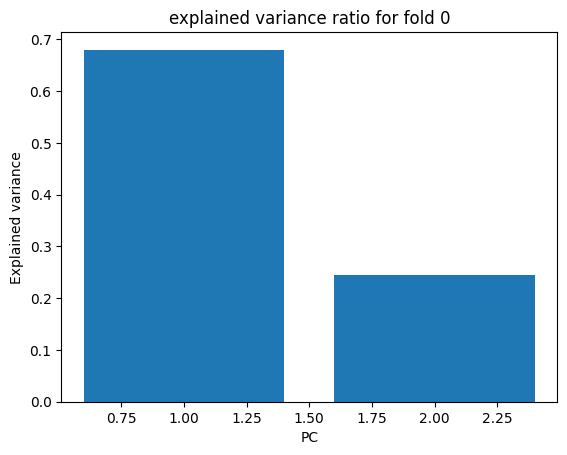

C:\Users\P095551\AppData\Local\Temp\ipykernel_35856\3520947247.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab20", len(patients))


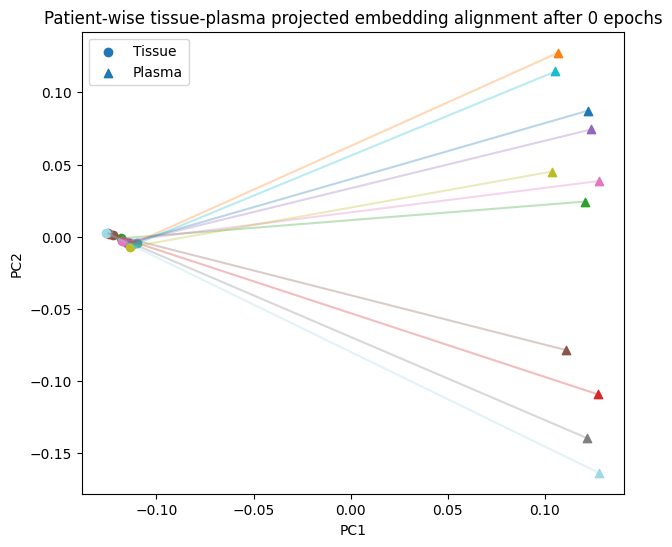

C:\Users\P095551\AppData\Local\Temp\ipykernel_35856\3520947247.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab20", len(patients))


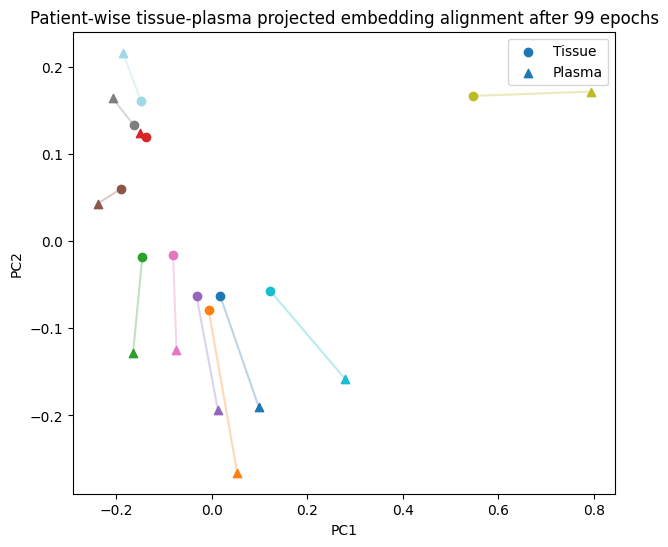

PC1 1.0
PC2 0.45454545454545453
Distances Fold 1
    PC  mean_distance  std_distance  fold
0  PC1       0.325953      0.055399     1
1  PC2       0.124844      0.049593     1
Fold 1 separation
    PC  modality_separation  tissue_mean  plasma_mean  fold
0  PC1             0.325953    -0.162977     0.162977     1
1  PC2             0.034068     0.017034    -0.017034     1


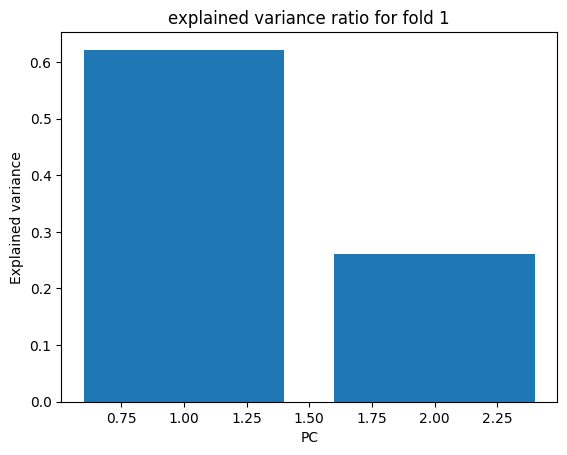

C:\Users\P095551\AppData\Local\Temp\ipykernel_35856\3520947247.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab20", len(patients))


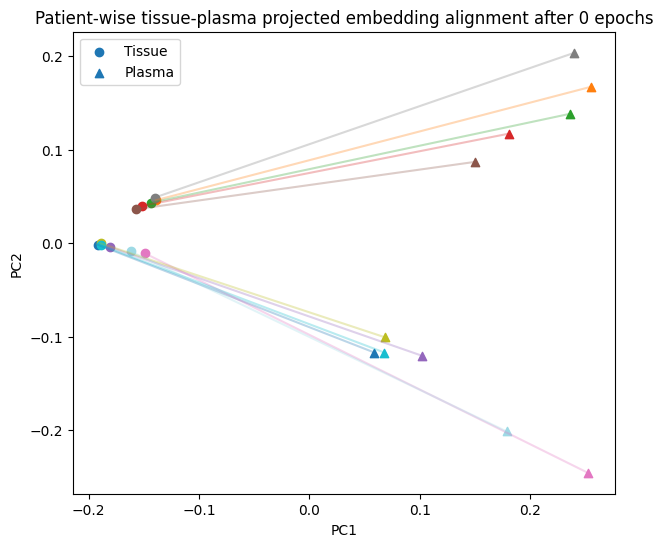

C:\Users\P095551\AppData\Local\Temp\ipykernel_35856\3520947247.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab20", len(patients))


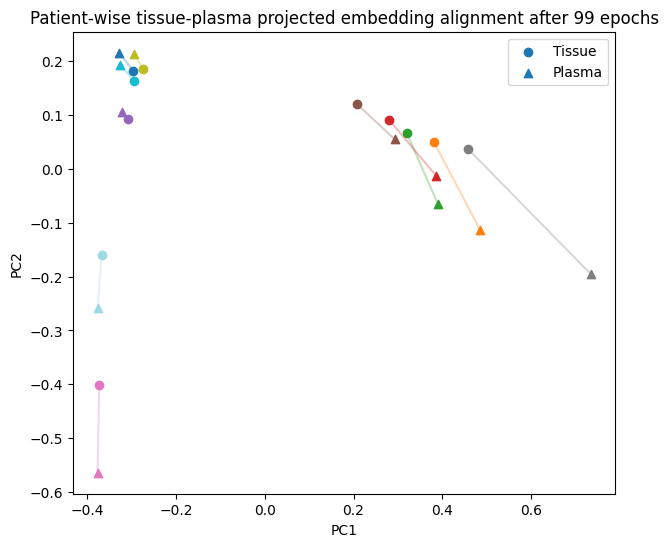

PC1 1.0
PC2 0.38
Distances Fold 2
    PC  mean_distance  std_distance  fold
0  PC1       0.251089      0.028566     2
1  PC2       0.080668      0.056765     2
Fold 2 separation
    PC  modality_separation  tissue_mean  plasma_mean  fold
0  PC1             0.251089    -0.125545     0.125545     2
1  PC2             0.028562     0.014281    -0.014281     2


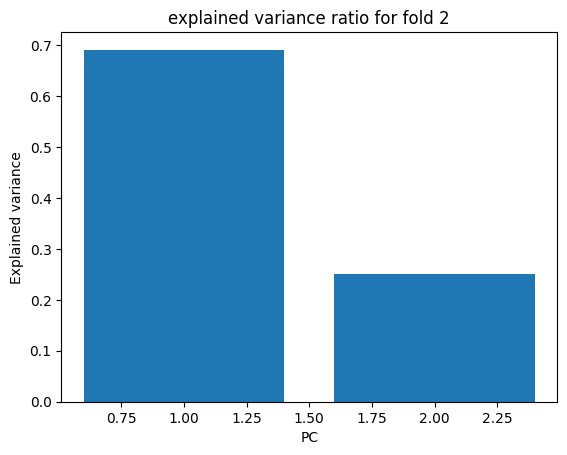

C:\Users\P095551\AppData\Local\Temp\ipykernel_35856\3520947247.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab20", len(patients))


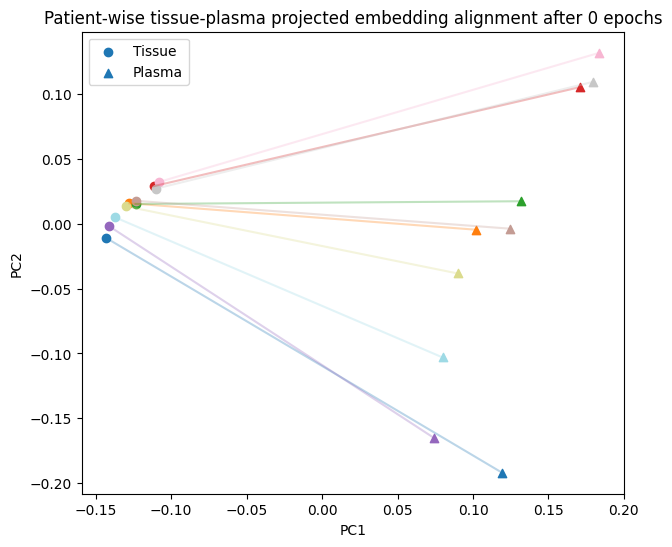

C:\Users\P095551\AppData\Local\Temp\ipykernel_35856\3520947247.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab20", len(patients))


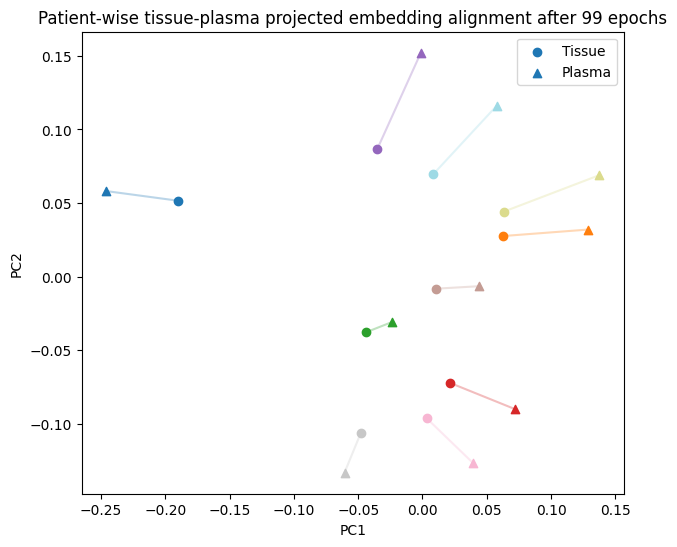

PC1 1.0
PC2 0.16
Distances Fold 3
    PC  mean_distance  std_distance  fold
0  PC1       0.263221      0.179833     3
1  PC2       0.146709      0.084584     3
Fold 3 separation
    PC  modality_separation  tissue_mean  plasma_mean  fold
0  PC1             0.263221    -0.131611     0.131611     3
1  PC2             0.140768     0.070384    -0.070384     3


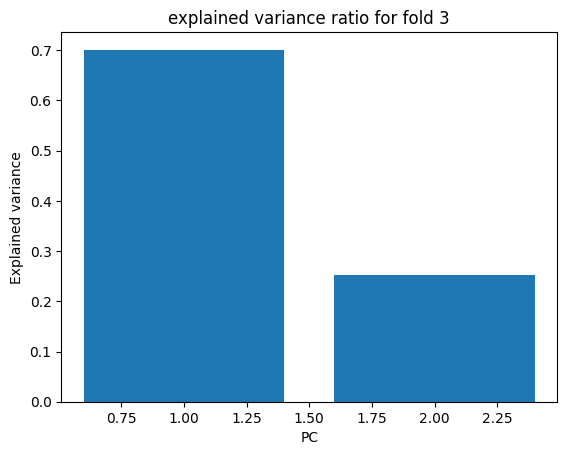

C:\Users\P095551\AppData\Local\Temp\ipykernel_35856\3520947247.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab20", len(patients))


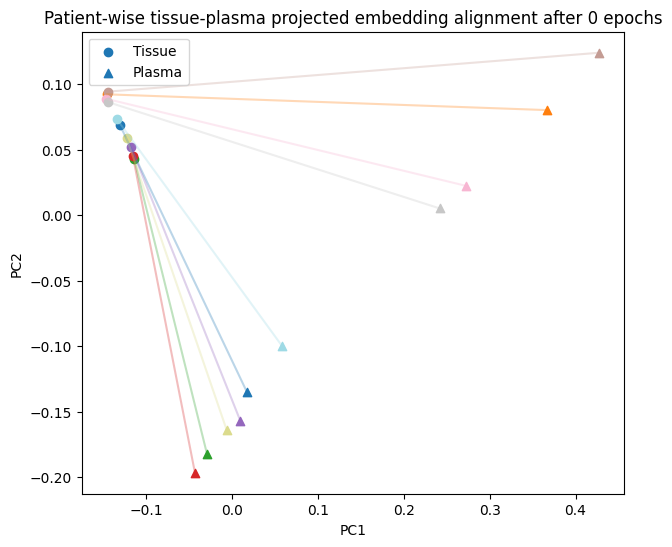

C:\Users\P095551\AppData\Local\Temp\ipykernel_35856\3520947247.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab20", len(patients))


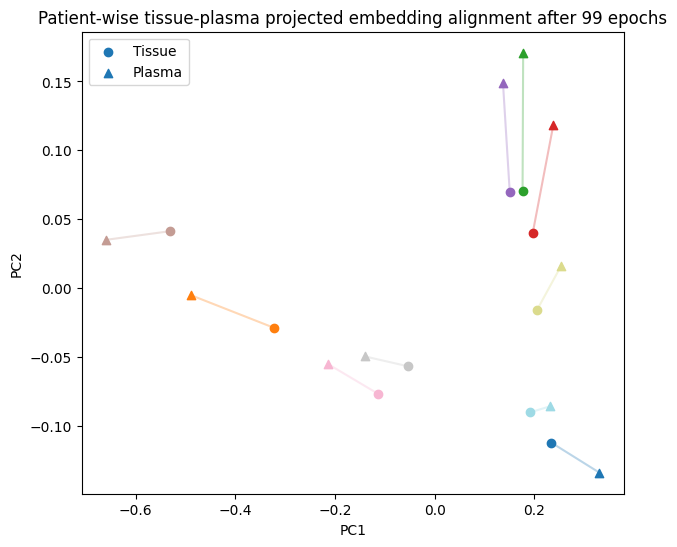

PC1 1.0
PC2 0.7
Distances Fold 4
    PC  mean_distance  std_distance  fold
0  PC1       0.291642      0.131346     4
1  PC2       0.132461      0.091129     4
Fold 4 separation
    PC  modality_separation  tissue_mean  plasma_mean  fold
0  PC1             0.291642    -0.145821     0.145821     4
1  PC2             0.113306    -0.056653     0.056653     4


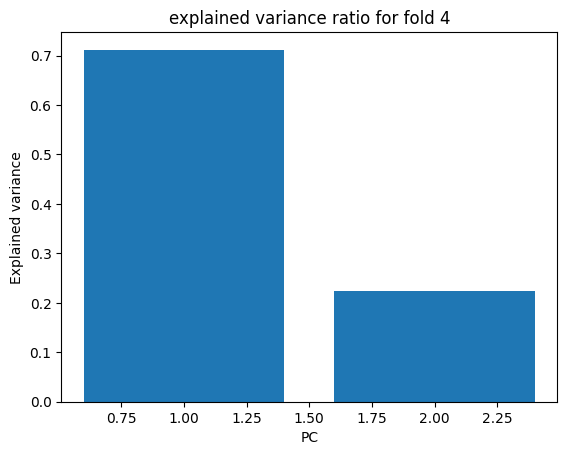

C:\Users\P095551\AppData\Local\Temp\ipykernel_35856\3520947247.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab20", len(patients))


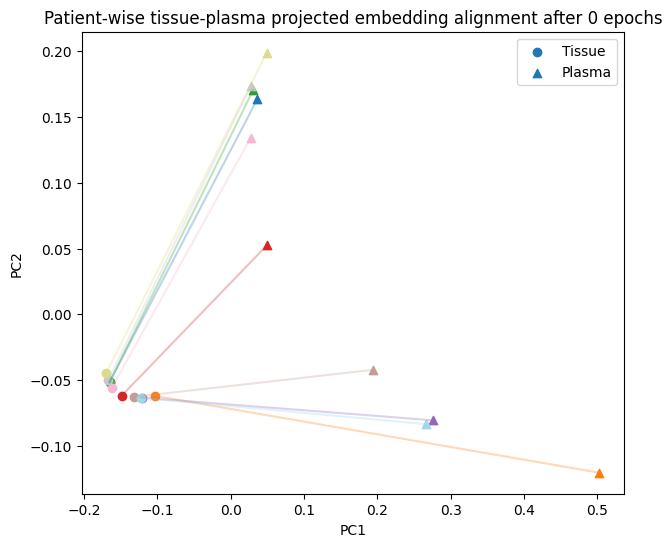

C:\Users\P095551\AppData\Local\Temp\ipykernel_35856\3520947247.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab20", len(patients))


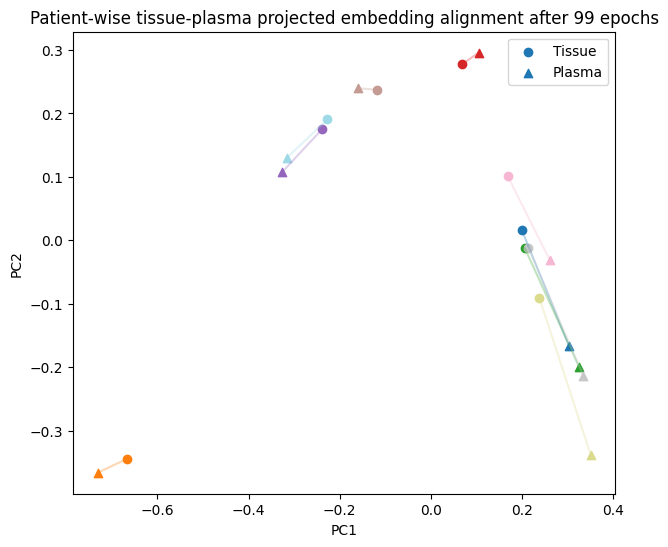

       patient modality       PC1       PC2  fold
0    Sample 15   Tissue -0.114247 -0.004474     0
1    Sample 15   Plasma  0.122235  0.087324     0
2    Sample 17   Tissue -0.112250 -0.005005     0
3    Sample 17   Plasma  0.106911  0.127434     0
4    Sample 28   Tissue -0.118247 -0.001110     0
..         ...      ...       ...       ...   ...
99   Sample 72   Plasma  0.027168  0.173597     4
100  Sample 77   Tissue -0.169770 -0.044583     4
101  Sample 77   Plasma  0.049032  0.198899     4
102  Sample 90   Tissue -0.122830 -0.063432     4
103  Sample 90   Plasma  0.266394 -0.083478     4

[104 rows x 5 columns]


In [24]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import matplotlib.cm as cm


def plot(pca_df, fold, proj=False, epoch=0):
    patients = sorted(
        set(pca_df["patient"])
    )

    # Create a color mapping for patients
    colors = cm.get_cmap("tab20", len(patients))
    patient_colors = {
        patient: colors(i)
        for i, patient in enumerate(patients)
    }

    plt.figure(figsize=(7, 6))

    for patient in patients:
        color = patient_colors[patient]

        tissue = pca_df[
            (pca_df["patient"] == patient) &
            (pca_df["modality"] == "Tissue")
            ].iloc[0]

        plasma = pca_df[
            (pca_df["patient"] == patient) &
            (pca_df["modality"] == "Plasma")
            ].iloc[0]

        t = tissue[["PC1", "PC2"]].values
        p = plasma[["PC1", "PC2"]].values

        plt.scatter(
            t[0],
            t[1],
            marker="o",
            color=color,
            label="Tissue" if patient == patients[0] else ""
        )

        plt.scatter(
            p[0],
            p[1],
            marker="^",
            color=color,
            label="Plasma" if patient == patients[0] else ""

        )

        plt.plot(
            [t[0], p[0]],
            [t[1], p[1]],
            color=color,
            alpha=0.3
        )

    if proj == True:
        emb_type = 'projected embedding'
    else:
        emb_type = 'encoded embedding'
    plt.title(
        f"Patient-wise tissue-plasma {emb_type} alignment after {epoch} epochs"
    )
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend()

    # plt.savefig(f'embeddings/plots/embeddings_fold_{fold}_{epoch}_{emb_type}.png',
    #     bbox_inches="tight")
    plt.show()


def compute_PCA(plasma_emb, tissue_emb):
    X = []
    labels = []
    modalities = []
    patients = sorted(
        set(tissue_emb.keys()) &
        set(plasma_emb.keys())
    )

    for patient in patients:
        X.append(
            tissue_emb[patient].numpy()
        )
        labels.append(patient)
        modalities.append("Tissue")

        X.append(
            plasma_emb[patient].numpy()
        )
        labels.append(patient)
        modalities.append("Plasma")

    X = np.stack(X)
    pca = PCA(
        n_components=2
    )

    X_pca = pca.fit_transform(X)
    pca_df = pd.DataFrame({
        "patient": labels,
        "modality": modalities,
        "PC1": X_pca[:, 0],
        "PC2": X_pca[:, 1]
    })
    return pca, pca_df


def paired_distances_per_pc(pca_df):
    pc_cols = [c for c in pca_df.columns if c.startswith("PC")]

    results = []

    for pc in pc_cols:

        distances = []

        for patient in pca_df["patient"].unique():
            tissue = pca_df[
                (pca_df.patient == patient) &
                (pca_df.modality == "Tissue")
                ][pc].values[0]

            plasma = pca_df[
                (pca_df.patient == patient) &
                (pca_df.modality == "Plasma")
                ][pc].values[0]

            distances.append(abs(tissue - plasma))

        results.append({
            "PC": pc,
            "mean_distance": np.mean(distances),
            "std_distance": np.std(distances)
        })

    return pd.DataFrame(results)


def modality_separation(pca_df):
    pc_cols = [c for c in pca_df.columns if c.startswith("PC")]

    results = []

    for pc in pc_cols:
        tissue_values = pca_df[
            pca_df["modality"] == "Tissue"
            ][pc]

        plasma_values = pca_df[
            pca_df["modality"] == "Plasma"
            ][pc]

        separation = abs(
            tissue_values.mean() -
            plasma_values.mean()
        )

        results.append({
            "PC": pc,
            "modality_separation": separation,
            "tissue_mean": tissue_values.mean(),
            "plasma_mean": plasma_values.mean()
        })

    return pd.DataFrame(results)


def visualize_embeddings(proj=False, trained=True):
    all_pc_distances = []
    all_pc_separations = []
    all_variance = []
    pc_all_folds = {}

    for fold in range(5):
        if proj:
            emb = torch.load(
                f"embeddings/fold_{fold}_embeddings_proj.pt"
            )
        else:
            emb = torch.load(
                f"embeddings/fold_{fold}_embeddings.pt"
            )

        tissue_emb_0 = emb["epoch0"]["tissue"]
        plasma_emb_0 = emb["epoch0"]["plasma"]

        tissue_emb_99 = emb["epoch99"]["tissue"]
        plasma_emb_99 = emb["epoch99"]["plasma"]

        pca_0, pca_0_df = compute_PCA(plasma_emb_0, tissue_emb_0)
        pca_99, pca_99_df = compute_PCA(plasma_emb_99, tissue_emb_99)

        from sklearn.metrics import roc_auc_score
        if trained == True:
            pca_99_df['fold'] = fold
            pc_all_folds[fold] = pca_99_df.copy()
            for pc in ["PC1", "PC2"]:
                values = pca_99_df[pc].values

                labels = (
                        pca_99_df["modality"] == "Plasma"
                ).astype(int)

                auc = roc_auc_score(labels, values)

                print(pc, auc)

            distance = paired_distances_per_pc(pca_99_df)
            distance["fold"] = fold
            print(f'Distances Fold {fold}')
            print(distance)

            all_pc_distances.append(distance)

            separation = modality_separation(pca_99_df)
            separation["fold"] = fold

            print(f"Fold {fold} separation")
            print(separation)
            all_pc_separations.append(separation)

            explained_variance = pd.DataFrame({
                "PC": [f"PC{i + 1}" for i in range(len(pca_99.explained_variance_ratio_))],
                "explained_variance": pca_99.explained_variance_ratio_,
                "fold": fold
            })

            all_variance.append(explained_variance)

            plt.bar(
                range(1, 3),
                pca_99.explained_variance_ratio_,
            )
            plt.title(f'explained variance ratio for fold {fold}')
            plt.xlabel("PC")
            plt.ylabel("Explained variance")
            plt.show()
            plot(pca_0_df, fold=fold, proj=proj, epoch=0)
            plot(pca_99_df, fold=fold, proj=proj, epoch=99)

        else:
            pca_0_df['fold'] = fold
            pc_all_folds[fold] = pca_0_df.copy()
            for pc in ["PC1", "PC2"]:
                values = pca_0_df[pc].values

                labels = (
                        pca_0_df["modality"] == "Plasma"
                ).astype(int)

                auc = roc_auc_score(labels, values)

                print(pc, auc)

            distance = paired_distances_per_pc(pca_0_df)
            distance["fold"] = fold
            print(f'Distances Fold {fold}')
            print(distance)

            all_pc_distances.append(distance)

            separation = modality_separation(pca_0_df)
            separation["fold"] = fold

            print(f"Fold {fold} separation")
            print(separation)
            all_pc_separations.append(separation)

            explained_variance = pd.DataFrame({
                "PC": [f"PC{i + 1}" for i in range(len(pca_0.explained_variance_ratio_))],
                "explained_variance": pca_0.explained_variance_ratio_,
                "fold": fold
            })

            all_variance.append(explained_variance)

            plt.bar(
                range(1, 3),
                pca_0.explained_variance_ratio_,
            )
            plt.title(f'explained variance ratio for fold {fold}')
            plt.xlabel("PC")
            plt.ylabel("Explained variance")
            plt.show()
            plot(pca_0_df, fold=fold, proj=proj, epoch=0)
            plot(pca_99_df, fold=fold, proj=proj, epoch=99)

    all_pc_distances = pd.concat(
        all_pc_distances,
        ignore_index=True
    )
    all_pc_separations = pd.concat(all_pc_separations, ignore_index=True)
    all_variance = pd.concat(all_variance, ignore_index=True)

    pc_all_folds_df = pd.concat(
        pc_all_folds.values(),
        ignore_index=True
    )
    print(pc_all_folds_df)

    return pc_all_folds_df, all_pc_distances, all_pc_separations, all_variance


pc, all_distances, all_separations, all_variance = visualize_embeddings(proj=True, trained=False)


PC1 0.4710743801652893
PC2 0.3801652892561983
Distances Fold 0
    PC  mean_distance  std_distance  fold
0  PC1       0.068995      0.068403     0
1  PC2       0.079672      0.057680     0
Fold 0 separation
    PC  modality_separation  tissue_mean  plasma_mean  fold
0  PC1             0.039340    -0.019670     0.019670     0
1  PC2             0.062302     0.031151    -0.031151     0


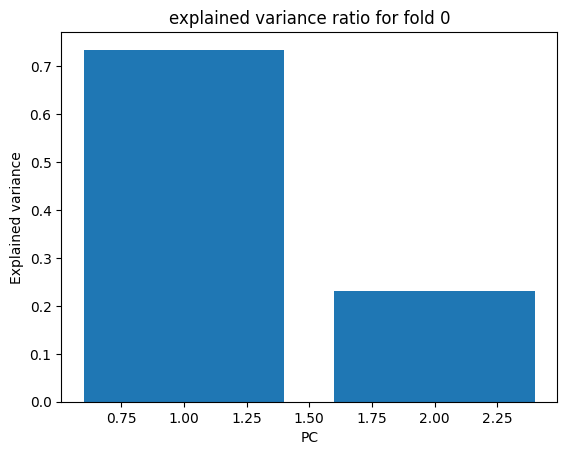

C:\Users\P095551\AppData\Local\Temp\ipykernel_35856\3520947247.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab20", len(patients))


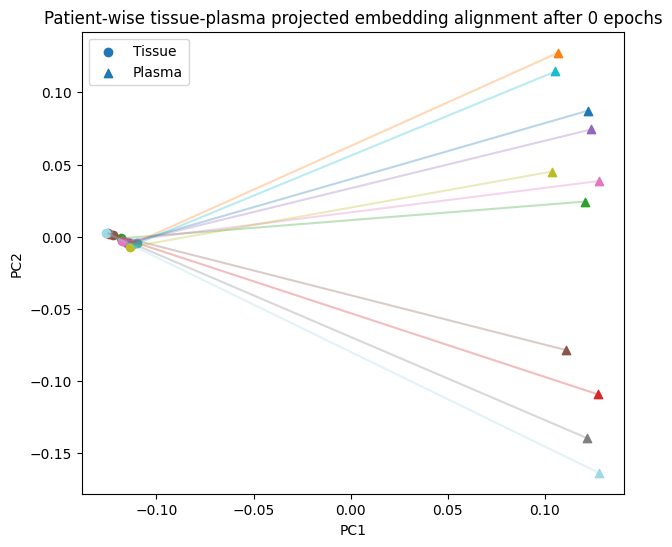

C:\Users\P095551\AppData\Local\Temp\ipykernel_35856\3520947247.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab20", len(patients))


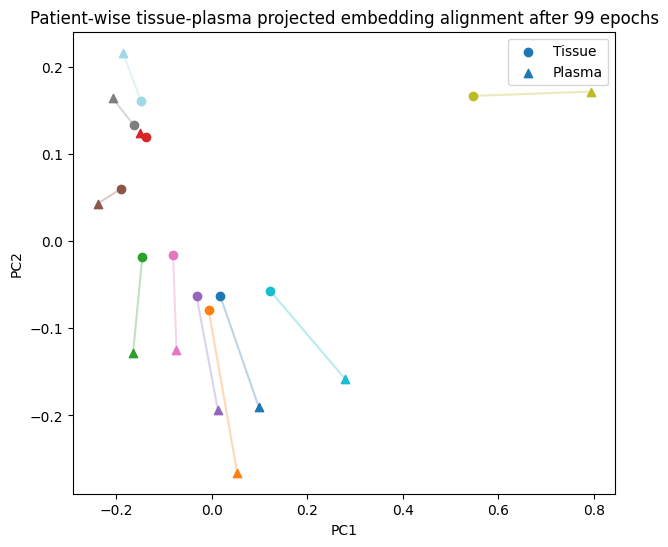

PC1 0.5041322314049587
PC2 0.4297520661157025
Distances Fold 1
    PC  mean_distance  std_distance  fold
0  PC1       0.068129      0.075019     1
1  PC2       0.096485      0.067172     1
Fold 1 separation
    PC  modality_separation  tissue_mean  plasma_mean  fold
0  PC1             0.048606    -0.024303     0.024303     1
1  PC2             0.077730     0.038865    -0.038865     1


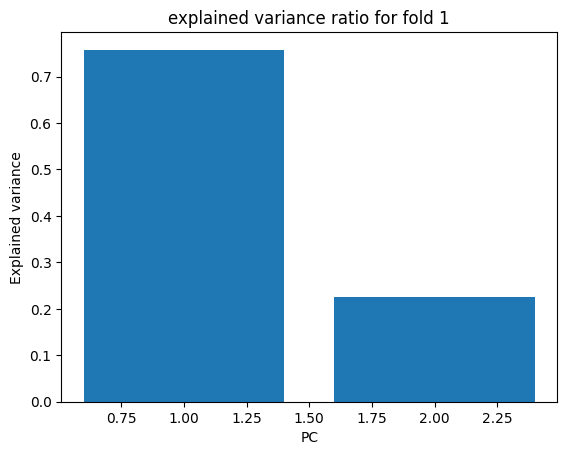

C:\Users\P095551\AppData\Local\Temp\ipykernel_35856\3520947247.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab20", len(patients))


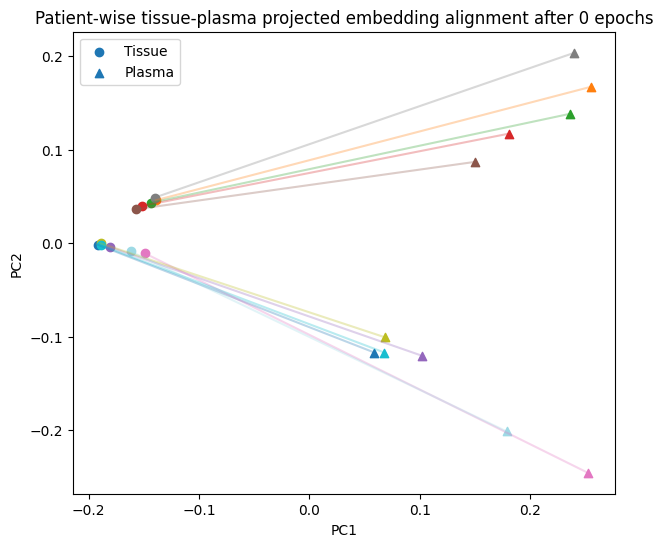

C:\Users\P095551\AppData\Local\Temp\ipykernel_35856\3520947247.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab20", len(patients))


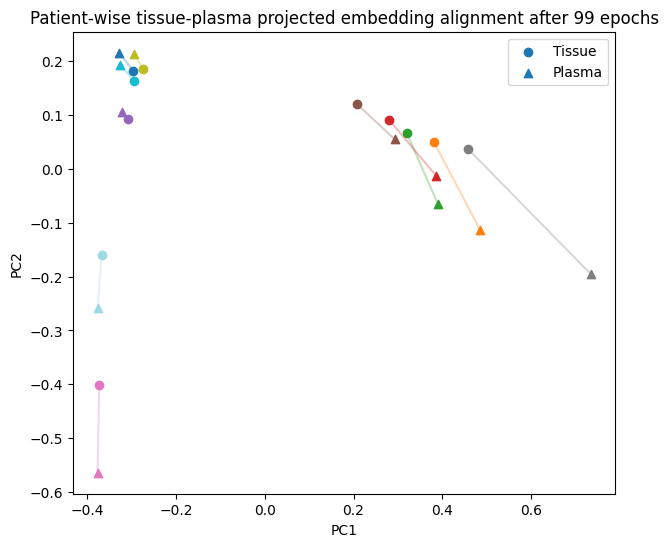

PC1 0.63
PC2 0.53
Distances Fold 2
    PC  mean_distance  std_distance  fold
0  PC1       0.043365      0.018570     2
1  PC2       0.023124      0.019384     2
Fold 2 separation
    PC  modality_separation  tissue_mean  plasma_mean  fold
0  PC1             0.029644    -0.014822     0.014822     2
1  PC2             0.008077    -0.004039     0.004039     2


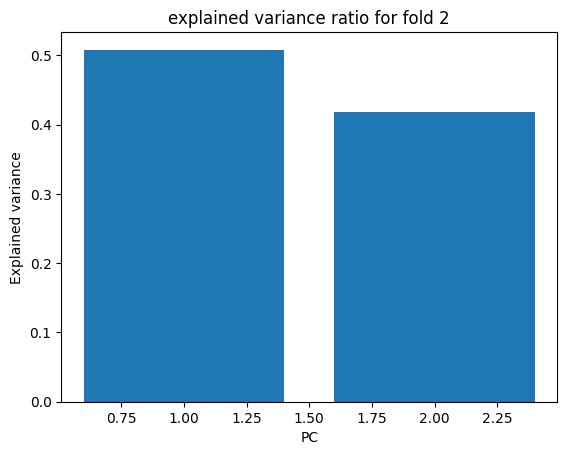

C:\Users\P095551\AppData\Local\Temp\ipykernel_35856\3520947247.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab20", len(patients))


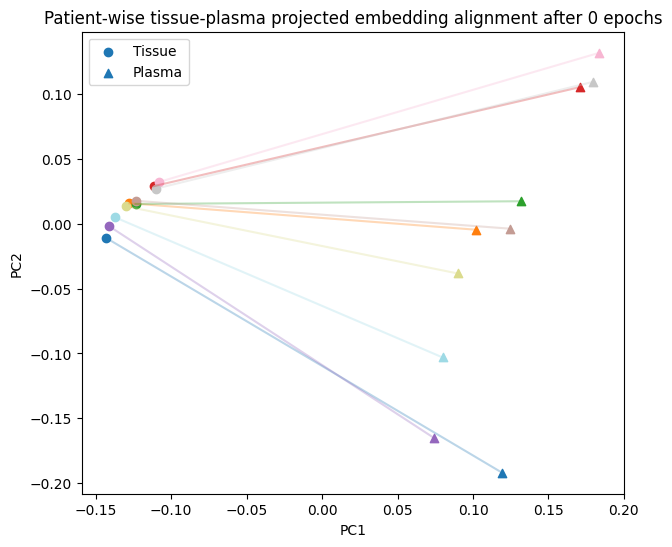

C:\Users\P095551\AppData\Local\Temp\ipykernel_35856\3520947247.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab20", len(patients))


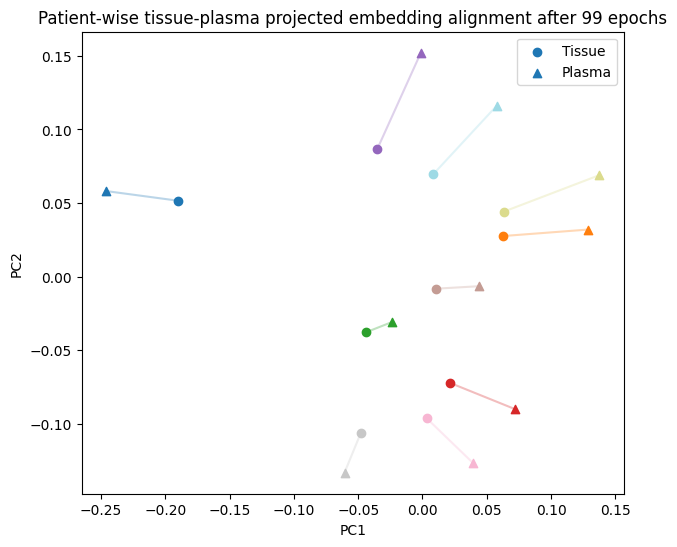

PC1 0.54
PC2 0.58
Distances Fold 3
    PC  mean_distance  std_distance  fold
0  PC1       0.072094       0.04934     3
1  PC2       0.037491       0.03330     3
Fold 3 separation
    PC  modality_separation  tissue_mean  plasma_mean  fold
0  PC1             0.026472     0.013236    -0.013236     3
1  PC2             0.031887    -0.015943     0.015943     3


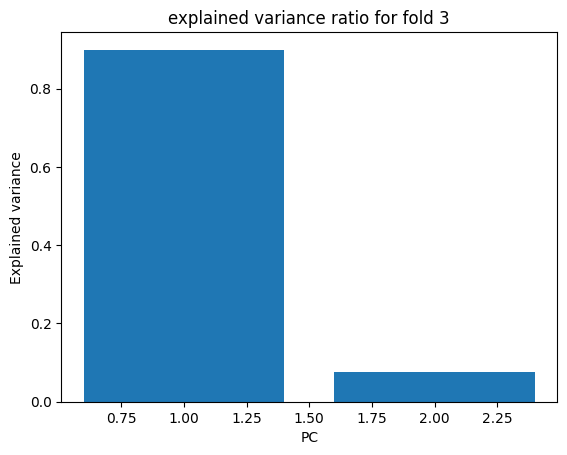

C:\Users\P095551\AppData\Local\Temp\ipykernel_35856\3520947247.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab20", len(patients))


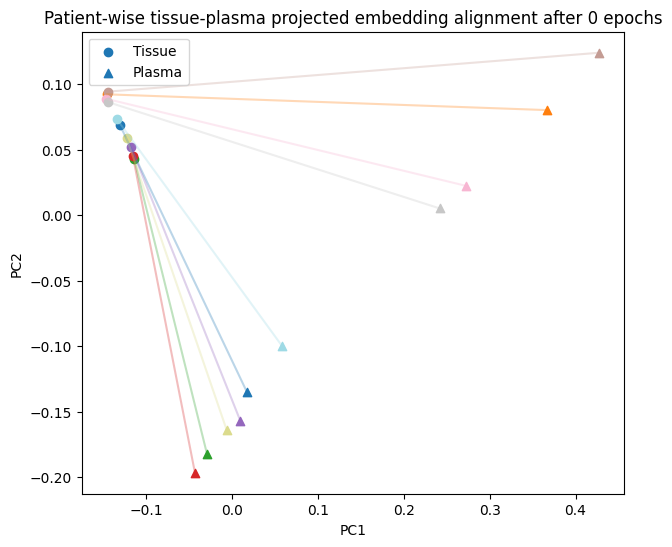

C:\Users\P095551\AppData\Local\Temp\ipykernel_35856\3520947247.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab20", len(patients))


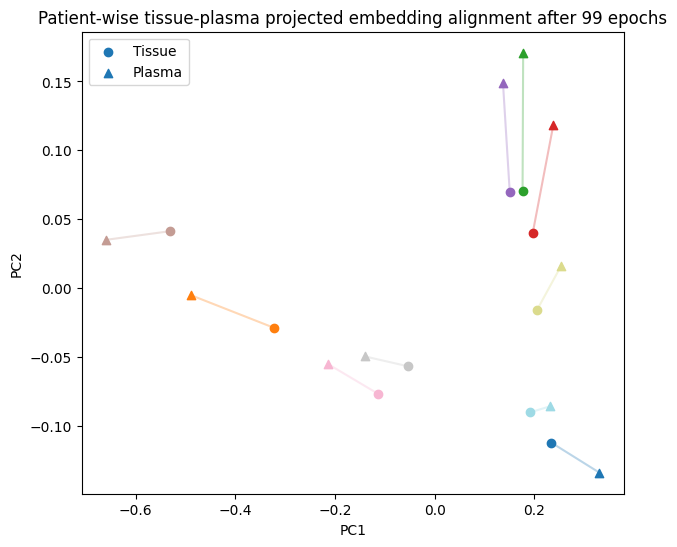

PC1 0.6
PC2 0.37
Distances Fold 4
    PC  mean_distance  std_distance  fold
0  PC1       0.086671      0.029092     4
1  PC2       0.112217      0.084498     4
Fold 4 separation
    PC  modality_separation  tissue_mean  plasma_mean  fold
0  PC1             0.030256    -0.015128     0.015128     4
1  PC2             0.108242     0.054121    -0.054121     4


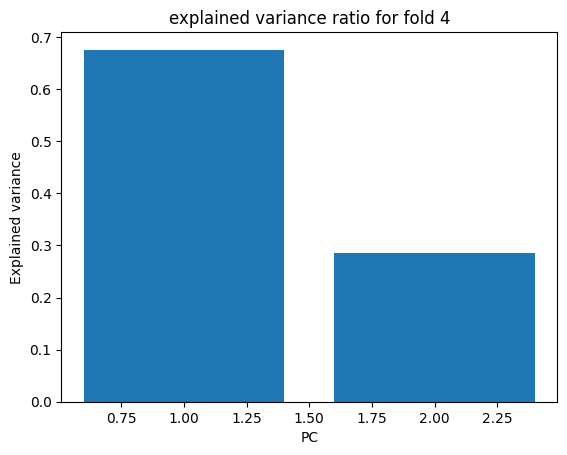

C:\Users\P095551\AppData\Local\Temp\ipykernel_35856\3520947247.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab20", len(patients))


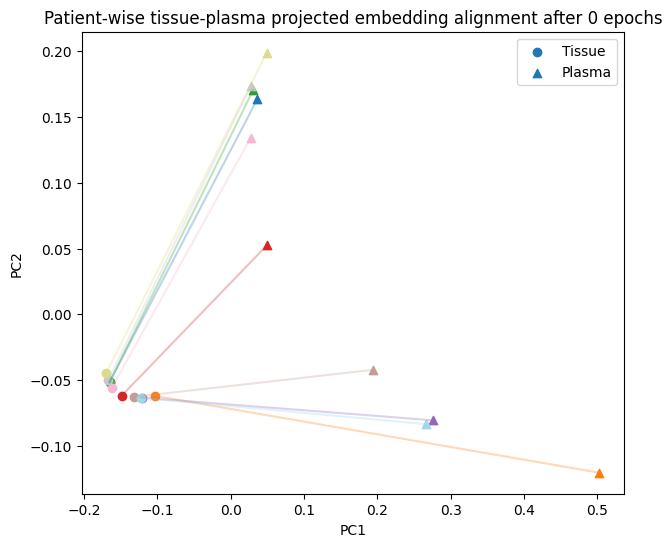

C:\Users\P095551\AppData\Local\Temp\ipykernel_35856\3520947247.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab20", len(patients))


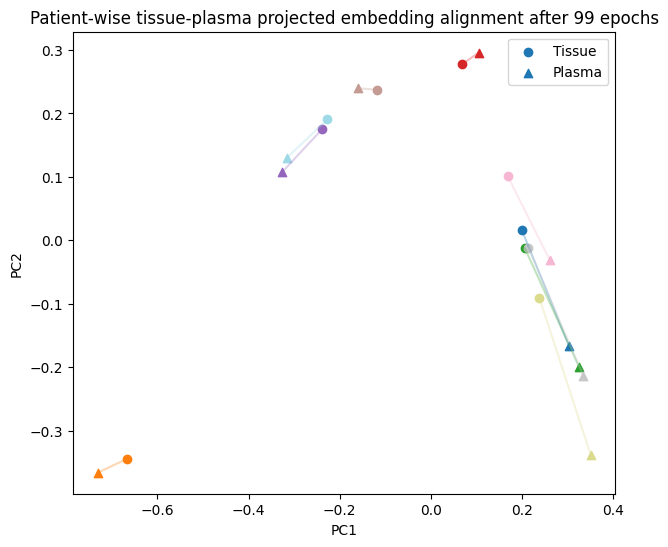

       patient modality       PC1       PC2  fold
0    Sample 15   Tissue  0.017644 -0.062865     0
1    Sample 15   Plasma  0.098205 -0.189830     0
2    Sample 17   Tissue -0.006294 -0.079543     0
3    Sample 17   Plasma  0.053302 -0.265687     0
4    Sample 28   Tissue -0.145562 -0.018652     0
..         ...      ...       ...       ...   ...
99   Sample 72   Plasma  0.335160 -0.213124     4
100  Sample 77   Tissue  0.238595 -0.090269     4
101  Sample 77   Plasma  0.351634 -0.338381     4
102  Sample 90   Tissue -0.226729  0.190697     4
103  Sample 90   Plasma -0.316056  0.130079     4

[104 rows x 5 columns]


In [25]:
pc_trained, all_distances_trained, all_separations_trained, all_variance_trained = visualize_embeddings(proj=True, trained=True)

In [5]:
print(pc_trained.head())

     patient modality       PC1       PC2  fold
0  Sample 15   Tissue  0.017644 -0.062865     0
1  Sample 15   Plasma  0.098205 -0.189830     0
2  Sample 17   Tissue -0.006294 -0.079543     0
3  Sample 17   Plasma  0.053302 -0.265687     0
4  Sample 28   Tissue -0.145562 -0.018652     0


In [296]:
summary_df = (
    all_distances
    .groupby("PC")
    .agg(
        mean_distance_across_folds=("mean_distance", "mean"),
        std_distance_across_folds=("std_distance", "mean")

    )
    .reset_index()
)

print(summary_df)

    PC  mean_distance_across_folds  std_distance_across_folds
0  PC1                    0.273609                   0.081607
1  PC2                    0.115853                   0.064835


In [297]:
summary_df_2 = all_separations.groupby("PC").agg(
        mean_separation_across_folds=("modality_separation", "mean")).reset_index()


print(summary_df_2)

    PC  mean_separation_across_folds
0  PC1                      0.273609
1  PC2                      0.064112


In [298]:
print(all_distances)

    PC  mean_distance  std_distance  fold
0  PC1       0.236139      0.012892     0
1  PC2       0.094584      0.042104     0
2  PC1       0.325953      0.055399     1
3  PC2       0.124844      0.049593     1
4  PC1       0.251089      0.028566     2
5  PC2       0.080668      0.056765     2
6  PC1       0.263221      0.179833     3
7  PC2       0.146709      0.084584     3
8  PC1       0.291642      0.131346     4
9  PC2       0.132461      0.091129     4


In [299]:
variance_summary = (
    all_variance
    .groupby("PC")
    .agg(
        mean_variance=("explained_variance", "mean"),
        std_variance=("explained_variance", "std")
    )
    .reset_index()
)

print(variance_summary)

    PC  mean_variance  std_variance
0  PC1       0.681030      0.035202
1  PC2       0.246549      0.013989


In [4]:
tissue_scores = pd.read_csv('PR80_30/tissue_pathway_scores.csv')
plasma_scores = pd.read_csv('PR80_30/plasma_pathway_scores.csv')

In [301]:
tissue_scores.columns

Index(['Name', 'REACTOME_ABC_FAMILY_PROTEINS_MEDIATED_TRANSPORT',
       'REACTOME_ABC_TRANSPORTER_DISORDERS',
       'REACTOME_ABORTIVE_ELONGATION_OF_HIV_1_TRANSCRIPT_IN_THE_ABSENCE_OF_TAT',
       'REACTOME_ACTIVATION_OF_AMPK_DOWNSTREAM_OF_NMDARS',
       'REACTOME_ACTIVATION_OF_ANTERIOR_HOX_GENES_IN_HINDBRAIN_DEVELOPMENT_DURING_EARLY_EMBRYOGENESIS',
       'REACTOME_ACTIVATION_OF_APC_C_AND_APC_C_CDC20_MEDIATED_DEGRADATION_OF_MITOTIC_PROTEINS',
       'REACTOME_ACTIVATION_OF_BH3_ONLY_PROTEINS',
       'REACTOME_ACTIVATION_OF_GENE_EXPRESSION_BY_SREBF_SREBP',
       'REACTOME_ACTIVATION_OF_NF_KAPPAB_IN_B_CELLS',
       ...
       'REACTOME_UBIQUITIN_DEPENDENT_DEGRADATION_OF_CYCLIN_D',
       'REACTOME_UBIQUITIN_MEDIATED_DEGRADATION_OF_PHOSPHORYLATED_CDC25A',
       'REACTOME_UB_SPECIFIC_PROCESSING_PROTEASES', 'REACTOME_UCH_PROTEINASES',
       'REACTOME_UNFOLDED_PROTEIN_RESPONSE_UPR',
       'REACTOME_VASOPRESSIN_REGULATES_RENAL_WATER_HOMEOSTASIS_VIA_AQUAPORINS',
       'REACTOME_VEGFR

In [5]:
pathways_1 = set(tissue_scores.columns).intersection(plasma_scores.columns) 
pathways_1.discard('Name')
print(pathways_1)

{'REACTOME_CILIUM_ASSEMBLY', 'REACTOME_DEUBIQUITINATION', 'REACTOME_SARS_COV_2_HOST_INTERACTIONS', 'REACTOME_DEGRADATION_OF_AXIN', 'REACTOME_EXTRACELLULAR_MATRIX_ORGANIZATION', 'REACTOME_DEVELOPMENTAL_CELL_LINEAGES_OF_THE_INTEGUMENTARY_SYSTEM', 'REACTOME_CLASS_I_MHC_MEDIATED_ANTIGEN_PROCESSING_PRESENTATION', 'REACTOME_PLASMA_LIPOPROTEIN_ASSEMBLY_REMODELING_AND_CLEARANCE', 'REACTOME_REGULATION_OF_T_CELL_ACTIVATION_BY_CD28_FAMILY', 'REACTOME_AUF1_HNRNP_D0_BINDS_AND_DESTABILIZES_MRNA', 'REACTOME_C_TYPE_LECTIN_RECEPTORS_CLRS', 'REACTOME_CELL_CELL_COMMUNICATION', 'REACTOME_TRANSCRIPTIONAL_REGULATION_BY_RUNX1', 'REACTOME_RAC3_GTPASE_CYCLE', 'REACTOME_AEROBIC_RESPIRATION_AND_RESPIRATORY_ELECTRON_TRANSPORT', 'REACTOME_SEPARATION_OF_SISTER_CHROMATIDS', 'REACTOME_KEAP1_NFE2L2_PATHWAY', 'REACTOME_M_PHASE', 'REACTOME_HSP90_CHAPERONE_CYCLE_FOR_STEROID_HORMONE_RECEPTORS_SHR_IN_THE_PRESENCE_OF_LIGAND', 'REACTOME_CELL_JUNCTION_ORGANIZATION', 'REACTOME_DECTIN_1_MEDIATED_NONCANONICAL_NF_KB_SIGNALING', '

In [31]:
print(pathways_1)

{'REACTOME_HEDGEHOG_ON_STATE', 'REACTOME_GSK3B_MEDIATED_PROTEASOMAL_DEGRADATION_OF_PD_L1_CD274', 'REACTOME_SEPARATION_OF_SISTER_CHROMATIDS', 'REACTOME_SIGNALING_BY_WNT', 'REACTOME_G_ALPHA_Q_SIGNALLING_EVENTS', 'REACTOME_COOPERATION_OF_PREFOLDIN_AND_TRIC_CCT_IN_ACTIN_AND_TUBULIN_FOLDING', 'REACTOME_INTRACELLULAR_SIGNALING_BY_SECOND_MESSENGERS', 'REACTOME_REGULATION_OF_HOMOTYPIC_CELL_CELL_ADHESION', 'REACTOME_SIGNALING_BY_INTERLEUKINS', 'REACTOME_TOLL_LIKE_RECEPTOR_CASCADES', 'REACTOME_HOST_INTERACTIONS_OF_HIV_FACTORS', 'REACTOME_CELL_JUNCTION_ORGANIZATION', 'REACTOME_REGULATION_OF_EXPRESSION_OF_SLITS_AND_ROBOS', 'REACTOME_COPII_MEDIATED_VESICLE_TRANSPORT', 'REACTOME_FORMATION_OF_FIBRIN_CLOT_CLOTTING_CASCADE', 'REACTOME_PCP_CE_PATHWAY', 'REACTOME_IMMUNOREGULATORY_INTERACTIONS_BETWEEN_A_LYMPHOID_AND_A_NON_LYMPHOID_CELL', 'REACTOME_FCGR3A_MEDIATED_IL10_SYNTHESIS', 'REACTOME_CLEC7A_DECTIN_1_SIGNALING', 'REACTOME_DISEASES_OF_GLYCOSYLATION', 'REACTOME_HEDGEHOG_OFF_STATE', 'REACTOME_FBXL7_DOWN

In [303]:
print(pc.head())

     patient modality       PC1       PC2  fold
0  Sample 15   Tissue -0.114247 -0.004474     0
1  Sample 15   Plasma  0.122235  0.087324     0
2  Sample 17   Tissue -0.112250 -0.005005     0
3  Sample 17   Plasma  0.106911  0.127434     0
4  Sample 28   Tissue -0.118247 -0.001110     0


In [7]:
from scipy.stats import pearsonr, spearmanr
merged = tissue_scores.merge(
    plasma_scores,
    on="Name",
    suffixes=("_tissue", "_plasma")
)

results = []

for pathway in pathways_1:

    tissue_col = f"{pathway}_tissue"
    plasma_col = f"{pathway}_plasma"

    # Only keep patients with both scores
    valid = merged[[tissue_col, plasma_col]].dropna()

    if len(valid) < 3:
        continue

    pearson_r, pearson_p = pearsonr(
        valid[tissue_col],
        valid[plasma_col]
    )

    spearman_r, spearman_p = spearmanr(
        valid[tissue_col],
        valid[plasma_col]
    )

    results.append({
        "pathway": pathway,
        "n": len(valid),
        "pearson_r": pearson_r,
        "pearson_p": pearson_p,
        "spearman_r": spearman_r,
        "spearman_p": spearman_p
    })

pathway_correlations = pd.DataFrame(results)


In [8]:
print(pathway_correlations)

                                               pathway   n  pearson_r  \
0                             REACTOME_CILIUM_ASSEMBLY  52   0.308264   
1                            REACTOME_DEUBIQUITINATION  52   0.027262   
2                REACTOME_SARS_COV_2_HOST_INTERACTIONS  52   0.063642   
3                         REACTOME_DEGRADATION_OF_AXIN  52  -0.000891   
4           REACTOME_EXTRACELLULAR_MATRIX_ORGANIZATION  52   0.004654   
..                                                 ...  ..        ...   
304                   REACTOME_SEMAPHORIN_INTERACTIONS  52   0.019423   
305  REACTOME_RECRUITMENT_OF_NUMA_TO_MITOTIC_CENTRO...  52   0.258777   
306                         REACTOME_SIGNALING_BY_VEGF  52   0.113460   
307     REACTOME_ROLE_OF_PHOSPHOLIPIDS_IN_PHAGOCYTOSIS  52   0.179851   
308  REACTOME_METABOLISM_OF_CARBOHYDRATES_AND_CARBO...  52  -0.181742   

     pearson_p  spearman_r  spearman_p  
0     0.026193    0.350636    0.010819  
1     0.847862   -0.012806    0.928203  


In [26]:
pc_trained = pc_trained.rename(
    columns={
        col: f"trained_{col}"
        for col in pc_trained.columns
        if col.startswith("PC")
    }
)
pc = pc.merge(
    pc_trained,
    on=["patient", "modality","fold"],
    how="left"
)

In [27]:
tissue_pc = pc[
    pc["modality"] == "Tissue"
]
print(tissue_pc.head())
plasma_pc = pc[pc['modality'] == 'Plasma']
print(plasma_pc.head())
tissue_scores = tissue_scores.rename(columns={"Name": "patient"})
plasma_scores = plasma_scores.rename(columns={"Name": "patient"})

merged_plasma = plasma_pc.merge(
    plasma_scores,
    on="patient",
    how="inner"
)
merged_tissue = tissue_pc.merge(
    tissue_scores,
    on="patient",
    how="inner"
)

     patient modality       PC1       PC2  fold  trained_PC1  trained_PC2
0  Sample 15   Tissue -0.114247 -0.004474     0     0.017644    -0.062865
2  Sample 17   Tissue -0.112250 -0.005005     0    -0.006294    -0.079543
4  Sample 28   Tissue -0.118247 -0.001110     0    -0.145562    -0.018652
6  Sample 29   Tissue -0.124198  0.001897     0    -0.137235     0.119316
8  Sample 34   Tissue -0.115161 -0.004311     0    -0.031901    -0.062717
     patient modality       PC1       PC2  fold  trained_PC1  trained_PC2
1  Sample 15   Plasma  0.122235  0.087324     0     0.098205    -0.189830
3  Sample 17   Plasma  0.106911  0.127434     0     0.053302    -0.265687
5  Sample 28   Plasma  0.120667  0.024360     0    -0.164712    -0.128584
7  Sample 29   Plasma  0.127350 -0.109119     0    -0.149998     0.124097
9  Sample 34   Plasma  0.123724  0.074271     0     0.013077    -0.194255


In [19]:
print(merged_tissue)

      patient modality       PC1       PC2  fold_x  trained_PC1  trained_PC2  \
0   Sample 15   Tissue -0.114247 -0.004474       0     0.017644    -0.062865   
1   Sample 17   Tissue -0.112250 -0.005005       0    -0.006294    -0.079543   
2   Sample 28   Tissue -0.118247 -0.001110       0    -0.145562    -0.018652   
3   Sample 29   Tissue -0.124198  0.001897       0    -0.137235     0.119316   
4   Sample 34   Tissue -0.115161 -0.004311       0    -0.031901    -0.062717   
5   Sample 38   Tissue -0.122609  0.001482       0    -0.190667     0.059800   
6   Sample 61   Tissue -0.117630 -0.003019       0    -0.080890    -0.016203   
7   Sample 76   Tissue -0.124838  0.002471       0    -0.163128     0.133106   
8   Sample 78   Tissue -0.113882 -0.007196       0     0.547475     0.166566   
9   Sample 85   Tissue -0.109865 -0.004668       0     0.122286    -0.057097   
10  Sample 88   Tissue -0.125839  0.002729       0    -0.148101     0.160952   
11  Sample 16   Tissue -0.191889 -0.0014

In [28]:
from scipy.stats import pearsonr, spearmanr


def correlate_pc_pathways(df, pc_cols=("PC1", "PC2","trained_PC1","trained_PC2")):
    results = []

    # pathway columns = everything except metadata + PCs
    metadata = {"patient", "modality", "fold", "Name"}
    pathway_cols = [
        col for col in df.columns
        if col not in metadata and col not in pc_cols
    ]

    for pc in pc_cols:
        for pathway in pathway_cols:

            # Remove missing values for this particular pair
            valid = df[[pc, pathway]].dropna()

            if len(valid) < 3:
                continue

            pearson_r, pearson_p = pearsonr(
                valid[pc],
                valid[pathway]
            )

            spearman_r, spearman_p = spearmanr(
                valid[pc],
                valid[pathway]
            )

            results.append({
                "PC": pc,
                "pathway": pathway,
                "n": len(valid),
                "pearson_r": pearson_r,
                "pearson_p": pearson_p,
                "spearman_r": spearman_r,
                "spearman_p": spearman_p
            })

    return pd.DataFrame(results)

In [29]:
from statsmodels.stats.multitest import multipletests

def add_fdr(results):

    results = results.copy()

    results["pearson_fdr"] = multipletests(
        results["pearson_p"],
        method="fdr_bh"
    )[1]

    results["spearman_fdr"] = multipletests(
        results["spearman_p"],
        method="fdr_bh"
    )[1]

    return results

In [30]:
tissue_results = []

for fold in range(5):

    fold_df = merged_tissue[
        merged_tissue["fold"] == fold
    ]

    result = correlate_pc_pathways(fold_df)
    result["fold"] = fold

    tissue_results.append(result)

tissue_results = pd.concat(
    tissue_results,
    ignore_index=True
)

tissue_results.sort_values(
    "pearson_r",
    ascending=False
).head(20)


,PC,pathway,n,pearson_r,pearson_p,spearman_r,spearman_p,fold
13961,PC2,REACTOME_RHO_GTPASES_ACTIVATE_CIT,10,0.965613,0.000006,0.842424,0.002220,4
13965,PC2,REACTOME_RHO_GTPASES_ACTIVATE_PAKS,10,0.956957,0.000014,0.781818,0.007547,4
13967,PC2,REACTOME_RHO_GTPASES_ACTIVATE_ROCKS,10,0.946269,0.000034,0.793939,0.006100,4
14072,PC2,REACTOME_SMOOTH_MUSCLE_CONTRACTION,10,0.936392,0.000066,0.793939,0.006100,4
13966,PC2,REACTOME_RHO_GTPASES_ACTIVATE_PKNS,10,0.933850,0.000077,0.696970,0.025097,4
14770,trained_PC1,REACTOME_RND2_GTPASE_CYCLE,10,0.911477,0.000241,0.939394,0.000055,4
13689,PC2,REACTOME_INOSITOL_PHOSPHATE_METABOLISM,10,0.887270,0.000615,0.793939,0.006100,4
10630,PC2,REACTOME_MOLECULES_ASSOCIATED_WITH_ELASTIC_FIBRES,10,0.886804,0.000625,0.878788,0.000814,3
10424,PC2,REACTOME_ELASTIC_FIBRE_FORMATION,10,0.877912,0.000837,0.878788,0.000814,3
13983,PC2,REACTOME_RND2_GTPASE_CYCLE,10,0.874307,0.000936,0.903030,0.000344,4


In [31]:
plasma_results = []

for fold in range(5):

    fold_df = merged_plasma[
        merged_plasma["fold"] == fold
    ]

    result = correlate_pc_pathways(fold_df)
    result["fold"] = fold

    plasma_results.append(result)

plasma_results = pd.concat(
    plasma_results,
    ignore_index=True
)
plasma_results.sort_values(
    "pearson_r",
    ascending=False
).head(20)


,PC,pathway,n,pearson_r,pearson_p,spearman_r,spearman_p,fold
5427,PC2,REACTOME_CELLULAR_RESPONSES_TO_STIMULI,10,0.989259,5.749330e-08,0.951515,2.279855e-05,4
5667,PC2,REACTOME_SIGNALING_BY_RHO_GTPASES_MIRO_GTPASES...,10,0.986824,1.297911e-07,0.842424,2.220031e-03,4
5643,PC2,REACTOME_SARS_COV_1_INFECTION,10,0.985899,1.700536e-07,0.830303,2.940227e-03,4
5635,PC2,REACTOME_RHO_GTPASE_EFFECTORS,10,0.985773,1.762163e-07,0.866667,1.173538e-03,4
5633,PC2,REACTOME_RHO_GTPASES_ACTIVATE_WASPS_AND_WAVES,10,0.985084,2.127119e-07,0.890909,5.421442e-04,4
1632,PC2,REACTOME_CILIUM_ASSEMBLY,11,0.981508,9.064351e-08,0.863636,6.116939e-04,1
1672,PC2,REACTOME_DISEASES_OF_SIGNAL_TRANSDUCTION_BY_GR...,11,0.980493,1.151075e-07,0.945455,1.118304e-05,1
5464,PC2,REACTOME_DENGUE_VIRUS_GENOME_TRANSLATION_AND_R...,10,0.978968,8.346136e-07,0.915152,2.044724e-04,4
1746,PC2,REACTOME_MEMBRANE_TRAFFICKING,11,0.978064,1.945071e-07,0.863636,6.116939e-04,1
5950,trained_PC1,REACTOME_RHO_GTPASES_ACTIVATE_WASPS_AND_WAVES,10,0.976804,1.231637e-06,0.878788,8.138621e-04,4


#### Cross modality pathway correlation

In [32]:
### Correlate tissue pc values with plasma pathway scores 
plasma_pathways = plasma_scores.copy()
tissue_pc_plasma_pathways = tissue_pc.merge(
    plasma_pathways,
    on="patient",
    how="inner"
)
cross_tissue_to_plasma = []

for fold in range(5):

    fold_df = tissue_pc_plasma_pathways[
        tissue_pc_plasma_pathways["fold"] == fold
    ]

    result = correlate_pc_pathways(fold_df)
    result["fold"] = fold

    cross_tissue_to_plasma.append(result)

cross_tissue_to_plasma = pd.concat(
    cross_tissue_to_plasma,
    ignore_index=True
)
cross_tissue_to_plasma.sort_values(
    "pearson_r",
    ascending=False
).head(20)


,PC,pathway,n,pearson_r,pearson_p,spearman_r,spearman_p,fold
1746,PC2,REACTOME_MEMBRANE_TRAFFICKING,11,0.983655,5.217337e-08,0.863636,0.000612,1
1830,PC2,REACTOME_RHO_GTPASE_CYCLE,11,0.983233,5.847611e-08,0.818182,0.002083,1
5755,trained_PC1,REACTOME_CLASS_I_MHC_MEDIATED_ANTIGEN_PROCESSI...,10,0.980310,6.421930e-07,0.939394,0.000055,4
1641,PC2,REACTOME_COOPERATION_OF_PREFOLDIN_AND_TRIC_CCT...,11,0.979140,1.553388e-07,0.863636,0.000612,1
1958,trained_PC1,REACTOME_COOPERATION_OF_PREFOLDIN_AND_TRIC_CCT...,11,0.978627,1.731686e-07,0.845455,0.001045,1
3097,PC2,REACTOME_RHO_GTPASES_ACTIVATE_WASPS_AND_WAVES,10,0.978286,9.474887e-07,0.927273,0.000112,2
1886,PC2,REACTOME_TRANSCRIPTIONAL_REGULATION_BY_TP53,11,0.978191,1.895388e-07,0.890909,0.000233,1
1797,PC2,REACTOME_RAC1_GTPASE_CYCLE,11,0.976949,2.427147e-07,0.863636,0.000612,1
1736,PC2,REACTOME_INTRA_GOLGI_AND_RETROGRADE_GOLGI_TO_E...,11,0.976268,2.764356e-07,0.836364,0.001333,1
1823,PC2,REACTOME_RHOBTB_GTPASE_CYCLE,11,0.976009,2.901824e-07,0.845455,0.001045,1


In [33]:
### Correlate plasma embedding/PC scores with tissue pathway scores
#### this is the important one
tissue_pathways = tissue_scores.copy()
plasma_pc_tissue_pathways = plasma_pc.merge(
    tissue_scores,
    on="patient",
    how="inner"
)

cross_plasma_to_tissue = []

for fold in range(5):

    fold_df = plasma_pc_tissue_pathways[
        plasma_pc_tissue_pathways["fold"] == fold
    ]

    result = correlate_pc_pathways(fold_df)
    result["fold"] = fold

    cross_plasma_to_tissue.append(result)

cross_plasma_to_tissue = pd.concat(
    cross_plasma_to_tissue,
    ignore_index=True
)


In [34]:
tissue_results = add_fdr(tissue_results)
plasma_results = add_fdr(plasma_results)

cross_tissue_to_plasma = add_fdr(cross_tissue_to_plasma)
cross_plasma_to_tissue = add_fdr(cross_plasma_to_tissue)

In [36]:
cross_plasma_to_tissue.sort_values(
    ["pearson_fdr",'spearman_fdr'],
    ascending=True
).head(20)


,PC,pathway,n,pearson_r,pearson_p,spearman_r,spearman_p,fold,pearson_fdr,spearman_fdr
13983,PC2,REACTOME_RND2_GTPASE_CYCLE,10,0.968980,0.000004,0.951515,0.000023,4,0.061421,0.287730
14770,trained_PC1,REACTOME_RND2_GTPASE_CYCLE,10,0.942483,0.000045,0.939394,0.000055,4,0.351432,0.287730
2217,trained_PC1,REACTOME_SIGNALING_BY_CSF1_M_CSF_IN_MYELOID_CELLS,11,0.887129,0.000271,0.863636,0.000612,0,0.851836,0.609302
5097,trained_PC1,REACTOME_METABOLISM_OF_STEROIDS,11,0.892266,0.000221,0.800000,0.003110,1,0.851836,0.625488
1997,trained_PC1,REACTOME_NERVOUS_SYSTEM_DEVELOPMENT,11,-0.890313,0.000239,-0.736364,0.009760,0,0.851836,0.673750
3372,PC1,REACTOME_FGFR1_MUTANT_RECEPTOR_ACTIVATION,11,0.818068,0.002089,0.927273,0.000040,1,0.932184,0.287730
14521,trained_PC1,REACTOME_LYSOSOME_VESICLE_BIOGENESIS,10,-0.745036,0.013411,-0.927273,0.000112,4,0.932184,0.440856
1904,trained_PC1,REACTOME_INTERLEUKIN_3_INTERLEUKIN_5_AND_GM_CS...,11,0.616642,0.043314,0.890909,0.000233,0,0.932184,0.540846
2122,trained_PC1,REACTOME_REGULATION_OF_SIGNALING_BY_CBL,11,0.771212,0.005447,0.881818,0.000330,0,0.932184,0.540846
4936,trained_PC1,REACTOME_FATTY_ACID_METABOLISM,11,0.795148,0.003439,0.881818,0.000330,1,0.932184,0.540846


In [37]:
summary_plasma_to_tissue = (
    cross_plasma_to_tissue
    .groupby(["PC", "pathway"])
    .agg(
        # Pearson
        pearson_mean_abs_r=("pearson_r", lambda x: x.abs().mean()),
        pearson_median_abs_r=("pearson_r", lambda x: x.abs().median()),
        pearson_min_abs_r=("pearson_r", lambda x: x.abs().min()),
        pearson_max_abs_r=("pearson_r", lambda x: x.abs().max()),

        # Spearman
        spearman_mean_abs_r=("spearman_r", lambda x: x.abs().mean()),
        spearman_median_abs_r=("spearman_r", lambda x: x.abs().median()),
        spearman_min_abs_r=("spearman_r", lambda x: x.abs().min()),
        spearman_max_abs_r=("spearman_r", lambda x: x.abs().max()),

        n_folds=("fold", "nunique"),
    )
    .reset_index()
)

print(summary_plasma_to_tissue)

               PC                                            pathway  \
0             PC1    REACTOME_ABC_FAMILY_PROTEINS_MEDIATED_TRANSPORT   
1             PC1                 REACTOME_ABC_TRANSPORTER_DISORDERS   
2             PC1  REACTOME_ABORTIVE_ELONGATION_OF_HIV_1_TRANSCRI...   
3             PC1   REACTOME_ACTIVATION_OF_AMPK_DOWNSTREAM_OF_NMDARS   
4             PC1  REACTOME_ACTIVATION_OF_ANTERIOR_HOX_GENES_IN_H...   
...           ...                                                ...   
3143  trained_PC2  REACTOME_VASOPRESSIN_REGULATES_RENAL_WATER_HOM...   
3144  trained_PC2     REACTOME_VEGFR2_MEDIATED_VASCULAR_PERMEABILITY   
3145  trained_PC2      REACTOME_VIF_MEDIATED_DEGRADATION_OF_APOBEC3G   
3146  trained_PC2             REACTOME_VIRAL_MESSENGER_RNA_SYNTHESIS   
3147  trained_PC2                  REACTOME_VISUAL_PHOTOTRANSDUCTION   

      pearson_mean_abs_r  pearson_median_abs_r  pearson_min_abs_r  \
0               0.248422              0.238717           0.051264 

In [41]:
summary_plasma_to_tissue[
    (summary_plasma_to_tissue["n_folds"] == 5)
].sort_values(['pearson_mean_abs_r','spearman_mean_abs_r'],
    ascending=False
).head(20)

,PC,pathway,pearson_mean_abs_r,pearson_median_abs_r,pearson_min_abs_r,pearson_max_abs_r,spearman_mean_abs_r,spearman_median_abs_r,spearman_min_abs_r,spearman_max_abs_r,n_folds
1873,trained_PC1,REACTOME_HSF1_DEPENDENT_TRANSACTIVATION,0.604048,0.615873,0.358101,0.796938,0.500000,0.466667,0.151515,0.745455,5
1811,trained_PC1,REACTOME_FORMATION_OF_THE_DYSTROPHIN_GLYCOPROT...,0.599783,0.651257,0.251394,0.820967,0.518788,0.406061,0.103030,0.866667,5
1618,trained_PC1,REACTOME_ATTENUATION_PHASE,0.598807,0.729664,0.285173,0.850475,0.496364,0.466667,0.236364,0.745455,5
1704,trained_PC1,REACTOME_DAP12_INTERACTIONS,0.597075,0.772984,0.131256,0.831997,0.618788,0.745455,0.187879,0.878788,5
1705,trained_PC1,REACTOME_DAP12_SIGNALING,0.579423,0.817640,0.031012,0.848756,0.581212,0.672727,0.030303,0.863636,5
1875,trained_PC1,REACTOME_IMMUNOREGULATORY_INTERACTIONS_BETWEEN...,0.549653,0.533501,0.496732,0.623680,0.430303,0.418182,0.260606,0.618182,5
2255,trained_PC1,REACTOME_SIGNALING_BY_TGFBR3,0.548930,0.699811,0.028565,0.791608,0.547879,0.612121,0.236364,0.818182,5
382,PC1,REACTOME_MITF_M_DEPENDENT_GENE_EXPRESSION,0.545675,0.546925,0.428482,0.691100,0.530909,0.587879,0.245455,0.745455,5
237,PC1,REACTOME_FORMATION_OF_THE_DYSTROPHIN_GLYCOPROT...,0.537063,0.551259,0.249038,0.800412,0.489697,0.551515,0.163636,0.769697,5
1468,PC2,REACTOME_SIGNALING_BY_TGFBR3,0.536637,0.521682,0.202311,0.772277,0.523636,0.624242,0.127273,0.793939,5


In [25]:
tissue_pc_plasma_pathways.head()

,patient,modality,PC1,PC2,fold,REACTOME_ABC_FAMILY_PROTEINS_MEDIATED_TRANSPORT,REACTOME_ABC_TRANSPORTER_DISORDERS,REACTOME_ACTIVATION_OF_APC_C_AND_APC_C_CDC20_MEDIATED_DEGRADATION_OF_MITOTIC_PROTEINS,REACTOME_ACTIVATION_OF_NF_KAPPAB_IN_B_CELLS,REACTOME_ADAPTIVE_IMMUNE_SYSTEM,...,REACTOME_TRANS_GOLGI_NETWORK_VESICLE_BUDDING,REACTOME_UBIQUITIN_DEPENDENT_DEGRADATION_OF_CYCLIN_D,REACTOME_UBIQUITIN_MEDIATED_DEGRADATION_OF_PHOSPHORYLATED_CDC25A,REACTOME_UB_SPECIFIC_PROCESSING_PROTEASES,REACTOME_UCH_PROTEINASES,REACTOME_UNFOLDED_PROTEIN_RESPONSE_UPR,REACTOME_VESICLE_MEDIATED_TRANSPORT,REACTOME_VIF_MEDIATED_DEGRADATION_OF_APOBEC3G,REACTOME_VIRAL_INFECTION_PATHWAYS,REACTOME_VISUAL_PHOTOTRANSDUCTION
0,Sample 15,Tissue,-0.114247,-0.004474,0,0.204250,0.214317,0.168489,0.149088,0.164303,...,-0.035744,0.168489,0.138505,0.100617,0.159640,0.036210,0.158433,0.128664,0.195283,0.390870
1,Sample 17,Tissue,-0.112250,-0.005005,0,0.026838,0.033465,-0.005519,-0.004788,0.180325,...,0.033403,-0.005519,-0.012768,-0.019499,0.016425,0.078718,0.205294,-0.021473,0.191556,0.366004
2,Sample 28,Tissue,-0.118247,-0.001110,0,0.159901,0.154310,0.112480,0.114566,0.221838,...,0.086650,0.112480,0.113977,0.100253,0.133214,0.133493,0.229199,0.124562,0.231783,0.271223
3,Sample 29,Tissue,-0.124198,0.001897,0,0.268874,0.266008,0.248693,0.235441,0.238812,...,0.123468,0.248693,0.225208,0.225463,0.243030,0.165831,0.241994,0.221681,0.262423,0.164421
4,Sample 34,Tissue,-0.115161,-0.004311,0,0.197636,0.194783,0.152219,0.132832,0.164300,...,-0.043331,0.152219,0.128396,0.087808,0.139243,0.115290,0.159399,0.118255,0.220068,0.403327


In [50]:
top_pearson_PC1 = (
    cross_plasma_to_tissue[(cross_plasma_to_tissue["PC"] == "PC1")]
    .groupby("pathway")
    .agg(
        mean_abs_r=("pearson_r", lambda x: x.abs().mean())
    )
    .sort_values("mean_abs_r", ascending=False)
    
    #.index
)
top_pearson_PC1_index = top_pearson_PC1[(top_pearson_PC1["mean_abs_r"] > 0.45)].index
top_pearson_PC2 = (
    cross_plasma_to_tissue[(cross_plasma_to_tissue["PC"] == "PC2")]
    .groupby("pathway")
    .agg(
        mean_abs_r=("pearson_r", lambda x: x.abs().mean())
    )
    .sort_values("mean_abs_r", ascending=False)

   # .index
)
top_pearson_PC2_index = top_pearson_PC2[(top_pearson_PC2["mean_abs_r"] > 0.45)].index
top_pearson_PC1_trained = (
    cross_plasma_to_tissue[(cross_plasma_to_tissue["PC"] == "trained_PC1")]
    .groupby("pathway")
    .agg(
        mean_abs_r=("pearson_r", lambda x: x.abs().mean())
    )
    .sort_values("mean_abs_r", ascending=False)
    
    #.index
)
top_pearson_PC1_trained_index = top_pearson_PC1_trained[(top_pearson_PC1_trained["mean_abs_r"] > 0.45)].index
top_pearson_PC2_trained = (
    cross_plasma_to_tissue[(cross_plasma_to_tissue["PC"] == "trained_PC2")]
    .groupby("pathway")
    .agg(
        mean_abs_r=("pearson_r", lambda x: x.abs().mean())
    )
    .sort_values("mean_abs_r", ascending=False)
   
   # .index
)
top_pearson_PC2_trained_index = top_pearson_PC2_trained[(top_pearson_PC2_trained["mean_abs_r"] > 0.45)].index

print(top_pearson_PC1_index)
print(top_pearson_PC2_index)
print(top_pearson_PC1_trained_index)
print(top_pearson_PC2_trained_index)

plot_data_PC2 = cross_plasma_to_tissue[
    (cross_plasma_to_tissue["PC"] == "PC2") &
    (cross_plasma_to_tissue["pathway"].isin(top_pearson_PC2_index))
].copy()

plot_data_PC2["abs_pearson_r"] = plot_data_PC2["pearson_r"].abs()

plot_df_PC2 = plot_data_PC2.pivot(
    index="pathway",
    columns="fold",
    values="abs_pearson_r"
)
plot_df_PC2

Index(['REACTOME_MITF_M_DEPENDENT_GENE_EXPRESSION',
       'REACTOME_FORMATION_OF_THE_DYSTROPHIN_GLYCOPROTEIN_COMPLEX_DGC',
       'REACTOME_SIGNALING_BY_TGFBR3', 'REACTOME_ATTENUATION_PHASE',
       'REACTOME_SMOOTH_MUSCLE_CONTRACTION',
       'REACTOME_HSF1_DEPENDENT_TRANSACTIVATION', 'REACTOME_RND3_GTPASE_CYCLE',
       'REACTOME_MITF_M_REGULATED_MELANOCYTE_DEVELOPMENT',
       'REACTOME_PLATELET_ADHESION_TO_EXPOSED_COLLAGEN',
       'REACTOME_RHO_GTPASES_ACTIVATE_PKNS',
       'REACTOME_PLATELET_ACTIVATION_SIGNALING_AND_AGGREGATION',
       'REACTOME_METABOLISM_OF_STEROIDS',
       'REACTOME_SIGNALING_BY_NOTCH1_PEST_DOMAIN_MUTANTS_IN_CANCER'],
      dtype='str', name='pathway')
Index(['REACTOME_SIGNALING_BY_TGFBR3', 'REACTOME_CD209_DC_SIGN_SIGNALING',
       'REACTOME_GPVI_MEDIATED_ACTIVATION_CASCADE',
       'REACTOME_HEPARAN_SULFATE_HEPARIN_HS_GAG_METABOLISM',
       'REACTOME_MITF_M_DEPENDENT_GENE_EXPRESSION'],
      dtype='str', name='pathway')
Index(['REACTOME_HSF1_DEPENDENT_T

fold,0,1,2,3,4
pathway,,,,,
REACTOME_CD209_DC_SIGN_SIGNALING,0.441713,0.637370,0.369204,0.745623,0.283007
REACTOME_GPVI_MEDIATED_ACTIVATION_CASCADE,0.645692,0.110162,0.542163,0.372251,0.769880
REACTOME_HEPARAN_SULFATE_HEPARIN_HS_GAG_METABOLISM,0.520207,0.594092,0.525078,0.609581,0.060491
REACTOME_MITF_M_DEPENDENT_GENE_EXPRESSION,0.145405,0.443226,0.478131,0.421090,0.777730
REACTOME_SIGNALING_BY_TGFBR3,0.202311,0.685621,0.521682,0.501291,0.772277


In [54]:
print(len(top_pearson_PC1))
print(len(top_pearson_PC2))
print(len(top_pearson_PC1_trained))
print(len(top_pearson_PC2_trained))

787
787
787
787


In [55]:
top_pearson_PC1

,mean_abs_r
pathway,
REACTOME_MITF_M_DEPENDENT_GENE_EXPRESSION,0.545675
REACTOME_FORMATION_OF_THE_DYSTROPHIN_GLYCOPROTEIN_COMPLEX_DGC,0.537063
REACTOME_SIGNALING_BY_TGFBR3,0.508794
REACTOME_ATTENUATION_PHASE,0.502559
REACTOME_SMOOTH_MUSCLE_CONTRACTION,0.500064
...,...
REACTOME_INTRAFLAGELLAR_TRANSPORT,0.082249
REACTOME_INTERFERON_SIGNALING,0.078823
REACTOME_MHC_CLASS_II_ANTIGEN_PRESENTATION,0.074740


In [58]:
results_comparison ={}
pathways = (set(top_pearson_PC1_trained_index)
    | set(top_pearson_PC2_trained_index))
print(pathways)
for pathway in pathways:
    results_comparison[pathway] = {
        "PC1": top_pearson_PC1.loc[pathway, "mean_abs_r"],
        "PC2": top_pearson_PC2.loc[pathway, "mean_abs_r"],
        "PC1_trained": top_pearson_PC1_trained.loc[pathway, "mean_abs_r"],
        "PC2_trained": top_pearson_PC2_trained.loc[pathway, "mean_abs_r"],
    }

results_comparison_df = pd.DataFrame.from_dict(
    results_comparison,
    orient="index"
)
results_comparison_df.head(10)
    

{'REACTOME_SENSORY_PERCEPTION', 'REACTOME_CILIUM_ASSEMBLY', 'REACTOME_SIGNALING_BY_TGFBR3', 'REACTOME_FCERI_MEDIATED_CA_2_MOBILIZATION', 'REACTOME_SENSORY_PROCESSING_OF_SOUND', 'REACTOME_NERVOUS_SYSTEM_DEVELOPMENT', 'REACTOME_RHO_GTPASE_EFFECTORS', 'REACTOME_IMMUNOREGULATORY_INTERACTIONS_BETWEEN_A_LYMPHOID_AND_A_NON_LYMPHOID_CELL', 'REACTOME_ANCHORING_OF_THE_BASAL_BODY_TO_THE_PLASMA_MEMBRANE', 'REACTOME_REGULATION_OF_CDH1_GENE_TRANSCRIPTION', 'REACTOME_MITOCHONDRIAL_BIOGENESIS', 'REACTOME_ORGANELLE_BIOGENESIS_AND_MAINTENANCE', 'REACTOME_CELL_SURFACE_INTERACTIONS_AT_THE_VASCULAR_WALL', 'REACTOME_G_PROTEIN_MEDIATED_EVENTS', 'REACTOME_MITF_M_DEPENDENT_GENE_EXPRESSION', 'REACTOME_INSULIN_PROCESSING', 'REACTOME_GPVI_MEDIATED_ACTIVATION_CASCADE', 'REACTOME_SIGNALING_BY_INTERLEUKINS', 'REACTOME_RHOD_GTPASE_CYCLE', 'REACTOME_FCERI_MEDIATED_MAPK_ACTIVATION', 'REACTOME_GLYCOGEN_METABOLISM', 'REACTOME_MITOTIC_SPINDLE_CHECKPOINT', 'REACTOME_HSF1_DEPENDENT_TRANSACTIVATION', 'REACTOME_INTERLEUKIN_4_

,PC1,PC2,PC1_trained,PC2_trained
REACTOME_SENSORY_PERCEPTION,0.344018,0.393456,0.454950,0.243985
REACTOME_CILIUM_ASSEMBLY,0.339625,0.306414,0.506089,0.253108
REACTOME_SIGNALING_BY_TGFBR3,0.508794,0.536637,0.548930,0.205099
REACTOME_FCERI_MEDIATED_CA_2_MOBILIZATION,0.368779,0.367932,0.485003,0.229551
REACTOME_SENSORY_PROCESSING_OF_SOUND,0.392870,0.370199,0.453357,0.172574
REACTOME_NERVOUS_SYSTEM_DEVELOPMENT,0.337767,0.335935,0.469621,0.225839
REACTOME_RHO_GTPASE_EFFECTORS,0.366510,0.321401,0.465410,0.339917
REACTOME_IMMUNOREGULATORY_INTERACTIONS_BETWEEN_A_LYMPHOID_AND_A_NON_LYMPHOID_CELL,0.407806,0.390000,0.549653,0.235458
REACTOME_ANCHORING_OF_THE_BASAL_BODY_TO_THE_PLASMA_MEMBRANE,0.344255,0.320581,0.503882,0.181404
REACTOME_REGULATION_OF_CDH1_GENE_TRANSCRIPTION,0.382494,0.359133,0.467064,0.213092


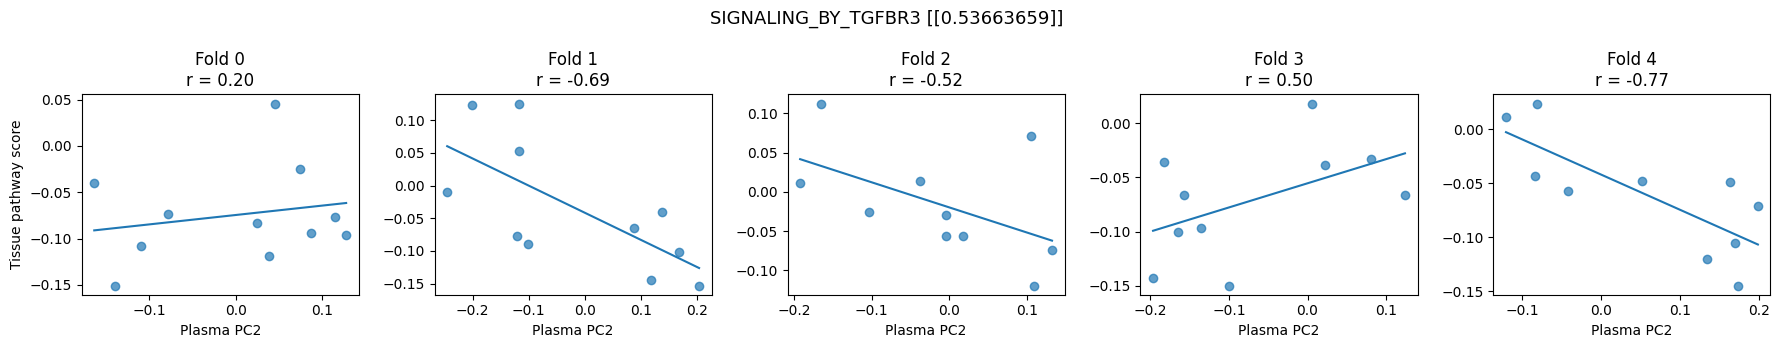

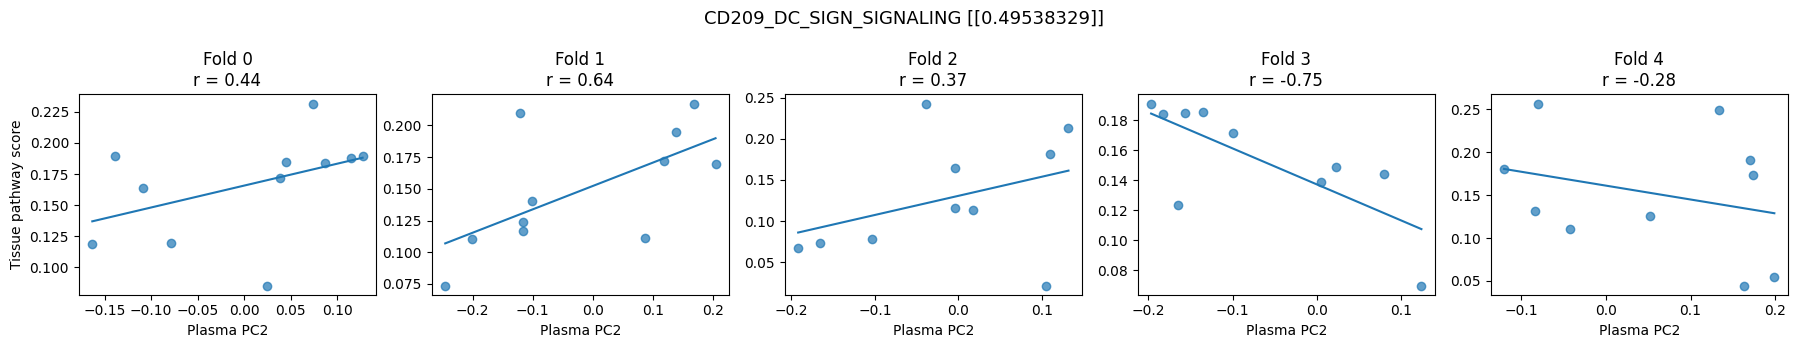

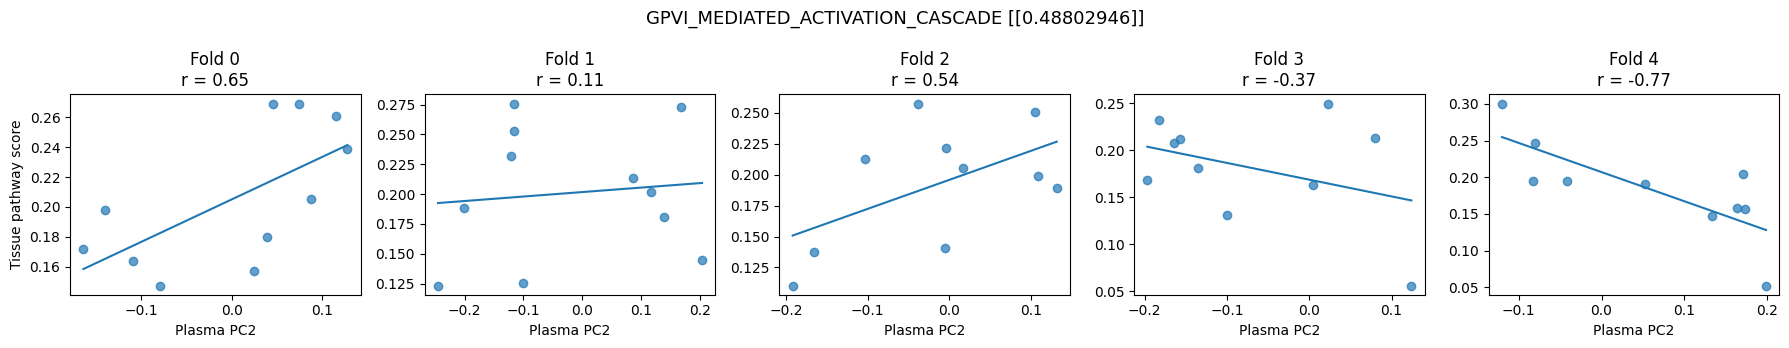

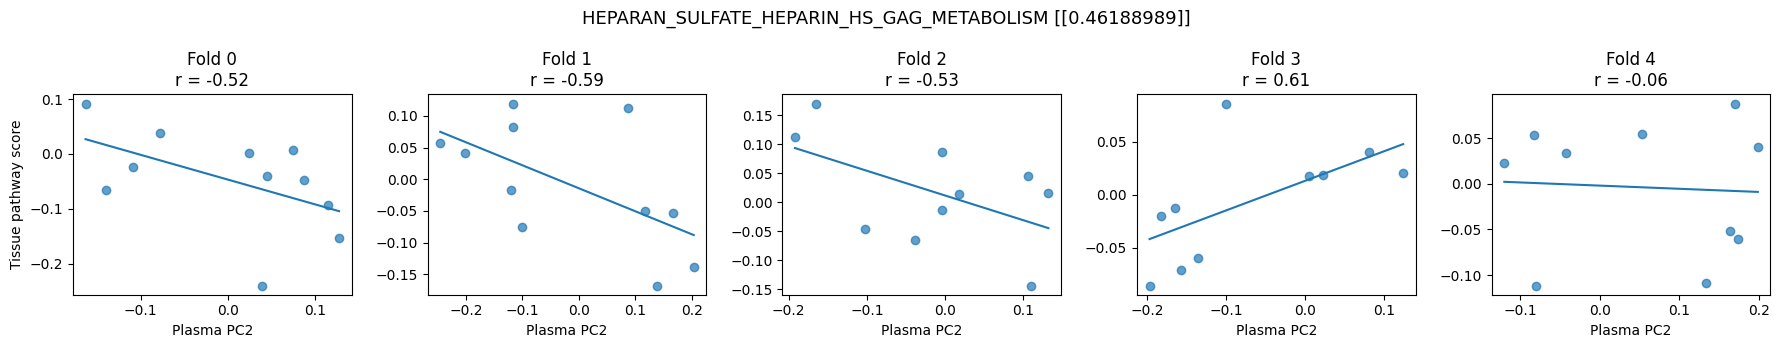

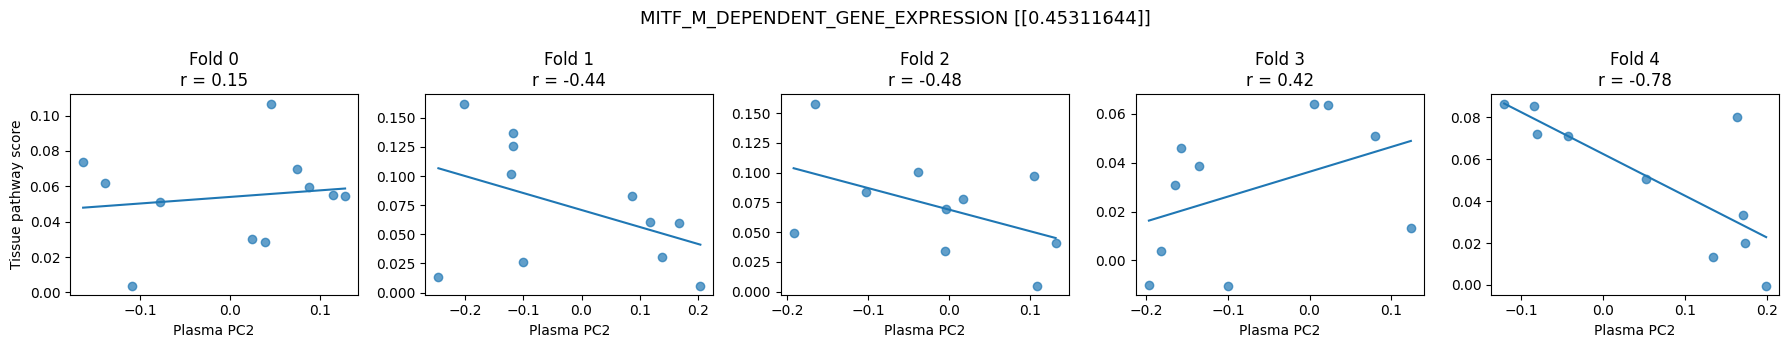

In [26]:
import matplotlib.pyplot as plt
import numpy as np

for pathway in top_pearson:

    pathway_df = cross_plasma_to_tissue[
        (cross_plasma_to_tissue["PC"] == "PC2") &
        (cross_plasma_to_tissue["pathway"] == pathway)
    ]

    fig, axes = plt.subplots(
        1, 5,
        figsize=(18, 3.5),
        sharex=False,
        sharey=False
    )

    for ax, (_, row) in zip(axes, pathway_df.iterrows()):

        fold = row["fold"]

        # Get the actual patient-level data for this fold
        fold_data = plasma_pc_tissue_pathways[
            plasma_pc_tissue_pathways["fold"] == fold
        ]

        x = fold_data["PC2"]
        y = fold_data[pathway]

        ax.scatter(x, y, alpha=0.7)

        # Regression line
        if len(x) >= 3:
            z = np.polyfit(x, y, 1)
            x_line = np.linspace(x.min(), x.max(), 100)
            y_line = z[0] * x_line + z[1]
            ax.plot(x_line, y_line)

        ax.set_title(
            f"Fold {int(fold)}\n"
            f"r = {row['pearson_r']:.2f}"
        )

        ax.set_xlabel("Plasma PC2")

    axes[0].set_ylabel("Tissue pathway score")
    abs_r = pathway_df.agg(pearson_mean_abs_r=("pearson_r", lambda x: x.abs().mean()))

    fig.suptitle(
        f'{pathway.replace("REACTOME_", "")} {(abs_r.values)}',
        fontsize=13
    )

    plt.tight_layout()
    plt.show()

In [27]:
top_pearson = (
    cross_plasma_to_tissue[
        cross_plasma_to_tissue["PC"] == "PC2"
    ]
    .groupby("pathway")
    .agg(
        mean_abs_r=("pearson_r", lambda x: x.abs().mean())
    )
    .sort_values("mean_abs_r", ascending=False)
    .head(10)
    .index
)

plot_data = cross_plasma_to_tissue[
    (cross_plasma_to_tissue["PC"] == "PC2") &
    (cross_plasma_to_tissue["pathway"].isin(top_pearson))
].copy()

plot_data["abs_pearson_r"] = plot_data["pearson_r"].abs()

plot_df = plot_data.pivot(
    index="pathway",
    columns="fold",
    values="abs_pearson_r"
)
plot_df

fold,0,1,2,3,4
pathway,,,,,
REACTOME_ATTENUATION_PHASE,0.411456,0.361409,0.024554,0.713361,0.738643
REACTOME_CD209_DC_SIGN_SIGNALING,0.441713,0.637370,0.369204,0.745623,0.283007
REACTOME_DAP12_SIGNALING,0.698712,0.283472,0.259407,0.163843,0.822838
REACTOME_EPH_EPHRIN_MEDIATED_REPULSION_OF_CELLS,0.234879,0.528096,0.295320,0.674233,0.507057
REACTOME_GPVI_MEDIATED_ACTIVATION_CASCADE,0.645692,0.110162,0.542163,0.372251,0.769880
REACTOME_HEPARAN_SULFATE_HEPARIN_HS_GAG_METABOLISM,0.520207,0.594092,0.525078,0.609581,0.060491
REACTOME_MITF_M_DEPENDENT_GENE_EXPRESSION,0.145405,0.443226,0.478131,0.421090,0.777730
REACTOME_RESPIRATORY_SYNCYTIAL_VIRUS_RSV_ATTACHMENT_AND_ENTRY,0.645533,0.278313,0.332303,0.542677,0.448375
REACTOME_SIGNALING_BY_SCF_KIT,0.748527,0.247309,0.413813,0.647004,0.193077


In [28]:
print(top_pearson)

Index(['REACTOME_SIGNALING_BY_TGFBR3', 'REACTOME_CD209_DC_SIGN_SIGNALING',
       'REACTOME_GPVI_MEDIATED_ACTIVATION_CASCADE',
       'REACTOME_HEPARAN_SULFATE_HEPARIN_HS_GAG_METABOLISM',
       'REACTOME_MITF_M_DEPENDENT_GENE_EXPRESSION',
       'REACTOME_SIGNALING_BY_SCF_KIT', 'REACTOME_ATTENUATION_PHASE',
       'REACTOME_RESPIRATORY_SYNCYTIAL_VIRUS_RSV_ATTACHMENT_AND_ENTRY',
       'REACTOME_EPH_EPHRIN_MEDIATED_REPULSION_OF_CELLS',
       'REACTOME_DAP12_SIGNALING'],
      dtype='str', name='pathway')


In [29]:
print(type(top_pearson))
print(type(pathway_correlations))
print(pathway_correlations.head())

<class 'pandas.Index'>


NameError: name 'pathway_correlations' is not defined

In [202]:
print(len(plot_data['pathway']))

50


In [214]:
pathway_comp = (
    cross_plasma_to_tissue[
        (cross_plasma_to_tissue["PC"] == "PC2") &
        (cross_plasma_to_tissue["pathway"].isin(top_pearson))
    ]
    .groupby("pathway")
    .agg(
        pc_pathway_abs_r=("pearson_r", lambda x: x.abs().mean())
    )
    .reset_index()
)

pathway_correlations_1 = pathway_correlations[
    pathway_correlations["pathway"].isin(top_pearson)
][["pathway", "pearson_r"]]

pathway_comp = pathway_comp.merge(
    pathway_correlations_1,
    on="pathway",
    how="left"
)

pathway_comp = pathway_comp.rename(columns={
    "pc_pathway_abs_r": "PC2 plasma → tissue pathway |r|",
    "pearson_r": "Plasma pathway ↔ tissue pathway r"
})

print(pathway_comp.head(10))

                                             pathway  \
0                         REACTOME_ATTENUATION_PHASE   
1                   REACTOME_CD209_DC_SIGN_SIGNALING   
2  REACTOME_CONSTITUTIVE_SIGNALING_BY_ABERRANT_PI...   
3    REACTOME_EPH_EPHRIN_MEDIATED_REPULSION_OF_CELLS   
4          REACTOME_GPVI_MEDIATED_ACTIVATION_CASCADE   
5                        REACTOME_INTEGRIN_SIGNALING   
6          REACTOME_MITF_M_DEPENDENT_GENE_EXPRESSION   
7                         REACTOME_RND3_GTPASE_CYCLE   
8                       REACTOME_SIGNALING_BY_TGFBR3   
9  REACTOME_SYNTHESIS_OF_PIPS_AT_THE_PLASMA_MEMBRANE   

   PC2 plasma → tissue pathway |r|  Plasma pathway ↔ tissue pathway r  
0                         0.464834                                NaN  
1                         0.499300                                NaN  
2                         0.457290                                NaN  
3                         0.460089                                NaN  
4                      

In [215]:
pathway_comp.head(10)

,pathway,PC2 plasma → tissue pathway |r|,Plasma pathway ↔ tissue pathway r
0,REACTOME_ATTENUATION_PHASE,0.464834,NaN
1,REACTOME_CD209_DC_SIGN_SIGNALING,0.499300,NaN
2,REACTOME_CONSTITUTIVE_SIGNALING_BY_ABERRANT_PI...,0.457290,NaN
3,REACTOME_EPH_EPHRIN_MEDIATED_REPULSION_OF_CELLS,0.460089,NaN
4,REACTOME_GPVI_MEDIATED_ACTIVATION_CASCADE,0.537829,NaN
5,REACTOME_INTEGRIN_SIGNALING,0.495519,-0.128994
6,REACTOME_MITF_M_DEPENDENT_GENE_EXPRESSION,0.472715,-0.228976
7,REACTOME_RND3_GTPASE_CYCLE,0.462946,NaN
8,REACTOME_SIGNALING_BY_TGFBR3,0.574773,NaN
9,REACTOME_SYNTHESIS_OF_PIPS_AT_THE_PLASMA_MEMBRANE,0.457041,NaN


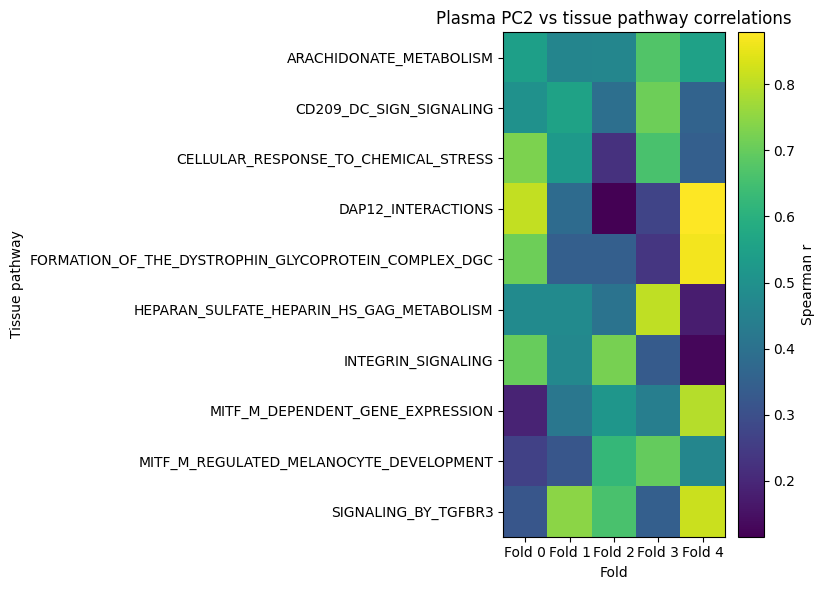

In [168]:
plt.figure(figsize=(8, 6))

plt.imshow(
    plot_df,
    aspect="auto"
)

plt.xticks(
    range(len(plot_df.columns)),
    [f"Fold {x}" for x in plot_df.columns]
)

plt.yticks(
    range(len(plot_df.index)),
    [
        x.replace("REACTOME_", "")
        for x in plot_df.index
    ]
)

plt.colorbar(label="Spearman r")

plt.xlabel("Fold")
plt.ylabel("Tissue pathway")
plt.title("Plasma PC2 vs tissue pathway correlations")

plt.tight_layout()
plt.show()

In [140]:
summary_plasma_to_tissue[
    (summary_plasma_to_tissue["PC"] == "PC2") &
    (summary_plasma_to_tissue["n_folds"] == 5)
].sort_values(['spearman_mean_abs_r'],
    ascending=False
).head(30)

,PC,pathway,pearson_mean_abs_r,pearson_median_abs_r,pearson_min_abs_r,pearson_max_abs_r,spearman_mean_abs_r,spearman_median_abs_r,spearman_min_abs_r,spearman_max_abs_r,n_folds
1468,PC2,REACTOME_SIGNALING_BY_TGFBR3,0.574773,0.516309,0.461192,0.774497,0.577576,0.660606,0.318182,0.818182,5
823,PC2,REACTOME_ARACHIDONATE_METABOLISM,0.434634,0.479960,0.153729,0.569800,0.540000,0.545455,0.463636,0.672727,5
855,PC2,REACTOME_CD209_DC_SIGN_SIGNALING,0.499300,0.481970,0.274181,0.753076,0.503030,0.500000,0.357576,0.709091,5
1024,PC2,REACTOME_FORMATION_OF_THE_DYSTROPHIN_GLYCOPROT...,0.415396,0.253318,0.123416,0.796729,0.500606,0.345455,0.236364,0.866667,5
861,PC2,REACTOME_CELLULAR_RESPONSE_TO_CHEMICAL_STRESS,0.367993,0.401709,0.074735,0.617684,0.496970,0.527273,0.224242,0.727273,5
917,PC2,REACTOME_DAP12_INTERACTIONS,0.400718,0.158422,0.028370,0.884269,0.491515,0.381818,0.115152,0.878788,5
1170,PC2,REACTOME_MITF_M_REGULATED_MELANOCYTE_DEVELOPMENT,0.418732,0.427511,0.127697,0.756171,0.473939,0.466667,0.263636,0.696970,5
1169,PC2,REACTOME_MITF_M_DEPENDENT_GENE_EXPRESSION,0.472715,0.440410,0.290073,0.715812,0.472121,0.442424,0.190909,0.793939,5
1104,PC2,REACTOME_INTEGRIN_SIGNALING,0.495519,0.390553,0.224675,0.797647,0.470909,0.472727,0.127273,0.721212,5
1075,PC2,REACTOME_HEPARAN_SULFATE_HEPARIN_HS_GAG_METABO...,0.411043,0.489249,0.063085,0.578344,0.470303,0.481818,0.175758,0.806061,5


In [129]:
cross_tissue_to_plasma[
    cross_tissue_to_plasma["PC"] == "PC2"
].sort_values(
    ["pearson_fdr",'spearman_r'],
    ascending=True
).head(50)


,PC,pathway,n,pearson_r,pearson_p,spearman_r,spearman_p,fold,pearson_fdr,spearman_fdr
2502,PC2,REACTOME_SIGNALING_BY_VEGF,10,-0.976303,0.000001,-0.842424,0.002220,3,0.000974,0.012567
2902,PC2,REACTOME_CLASS_I_MHC_MEDIATED_ANTIGEN_PROCESSI...,10,-0.971598,0.000003,-0.939394,0.000055,4,0.001012,0.003219
3036,PC2,REACTOME_NERVOUS_SYSTEM_DEVELOPMENT,10,-0.967378,0.000005,-0.830303,0.002940,4,0.001052,0.014406
2940,PC2,REACTOME_DISEASES_OF_SIGNAL_TRANSDUCTION_BY_GR...,10,-0.967011,0.000005,-0.818182,0.003815,4,0.001052,0.016254
1095,PC2,REACTOME_INTERFERON_SIGNALING,11,-0.953240,0.000006,-0.881818,0.000330,1,0.001097,0.006260
2864,PC2,REACTOME_ANTIGEN_PROCESSING_CROSS_PRESENTATION,10,-0.964607,0.000007,-0.769697,0.009222,4,0.001097,0.026624
1703,PC2,REACTOME_GLYCOSAMINOGLYCAN_METABOLISM,10,-0.959713,0.000011,-0.963636,0.000007,2,0.001138,0.001289
412,PC2,REACTOME_ELASTIC_FIBRE_FORMATION,11,-0.946442,0.000010,-0.936364,0.000022,0,0.001138,0.001853
965,PC2,REACTOME_ANTIMICROBIAL_MECHANISM_OF_IFN_STIMUL...,11,-0.942812,0.000014,-0.927273,0.000040,1,0.001138,0.002930
1152,PC2,REACTOME_PLATELET_AGGREGATION_PLUG_FORMATION,11,-0.947603,0.000009,-0.881818,0.000330,1,0.001138,0.006260


In [121]:
cross_tissue_to_plasma.columns

Index(['PC', 'pathway', 'n', 'pearson_r', 'pearson_p', 'spearman_r',
       'spearman_p', 'fold', 'pearson_fdr', 'spearman_fdr'],
      dtype='str')

In [116]:
cross_plasma_to_tissue[
    cross_plasma_to_tissue["PC"] == "PC2"
].sort_values(
    "pearson_r",
    ascending=True
).head(20)

,PC,pathway,n,pearson_r,pearson_p,spearman_r,spearman_p,fold,pearson_fdr,spearman_fdr
7687,PC2,REACTOME_RND2_GTPASE_CYCLE,10,-0.908319,0.000276,-0.939394,0.000055,4,0.593317,0.262128
917,PC2,REACTOME_DAP12_INTERACTIONS,11,-0.884269,0.000302,-0.809091,0.002559,0,0.593317,0.510981
918,PC2,REACTOME_DAP12_SIGNALING,11,-0.867467,0.000541,-0.809091,0.002559,0,0.709869,0.510981
7688,PC2,REACTOME_RND3_GTPASE_CYCLE,10,-0.843226,0.002177,-0.781818,0.007547,4,0.777489,0.535090
2617,PC2,REACTOME_GLUCOSE_METABOLISM,11,-0.834927,0.001384,-0.709091,0.014552,1,0.777489,0.612431
1014,PC2,REACTOME_FLT3_SIGNALING,11,-0.824939,0.001775,-0.836364,0.001333,0,0.777489,0.476917
1430,PC2,REACTOME_SIGNALING_BY_CSF1_M_CSF_IN_MYELOID_CELLS,11,-0.823350,0.001844,-0.881818,0.000330,0,0.777489,0.338028
1335,PC2,REACTOME_REGULATION_OF_SIGNALING_BY_CBL,11,-0.797743,0.003260,-0.818182,0.002083,0,0.873036,0.510981
1104,PC2,REACTOME_INTEGRIN_SIGNALING,11,-0.797647,0.003267,-0.700000,0.016471,0,0.873036,0.641716
7320,PC2,REACTOME_FORMATION_OF_THE_DYSTROPHIN_GLYCOPROT...,10,-0.796729,0.005797,-0.866667,0.001174,4,0.931096,0.461787
